# Explorative Datenanalyse: Santander Customer Transaction Prediction

**Datensatz:** OpenML `45566` (Santander Customer Transaction Prediction) — 200.000 Kunden,
200 anonymisierte numerische Features (`var_0`–`var_199`) und die binäre Zielvariable `target`.

Dieses Notebook deckt ausschließlich die explorative Datenanalyse ab: Datenqualität,
univariate Verteilungen, Zusammenhänge der Features mit der Zielvariable sowie eine
vertiefte Betrachtung der Werte-Häufigkeitsstruktur. Modellierung ist bewusst nicht Teil
dieses Notebooks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import mannwhitneyu, ttest_ind, false_discovery_control

## Daten laden und vorbereiten

In [2]:
data = fetch_openml(data_id=45566, as_frame=True)
df = data.frame

feature_columns = [c for c in df.columns if c.startswith("var")]

# target wird von OpenML als String-Kategorie ("False"/"True") geladen, nicht als Bool
df["target"] = df["target"].astype(str) == "True"

In [3]:
def check_downcast(original: pd.DataFrame, cols: list[str], atol: float = 1e-4) -> None:
    """Prueft, ob float64 -> float32 fuer die angegebenen Spalten unbedenklich ist."""
    orig = original[cols].to_numpy(dtype="float64")
    down = original[cols].astype("float32").to_numpy(dtype="float64")
    diff = np.abs(orig - down)
    print("max abs diff:  ", diff.max())
    print("mean abs diff: ", diff.mean())
    print(f"allclose (atol={atol:.0e})?", np.allclose(orig, down, atol=atol))


check_downcast(df, feature_columns)
df[feature_columns] = df[feature_columns].astype("float32")

max abs diff:   3.7963867214330094e-06
mean abs diff:  1.9811511402243882e-07
allclose (atol=1e-04)? True


## Stylesheet

In [4]:
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"]
)
SEQUENTIAL_ORANGE = LinearSegmentedColormap.from_list(
    "seq_orange", ["#f5f4f0", "#eb6834"]
)

INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

sns.set_theme(style="white")
mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": INK_MUTED,
    "axes.labelcolor": INK_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 1,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK,
    "font.family": "sans-serif",
    "legend.frameon": False,
    "axes.prop_cycle": mpl.cycler(color=CATEGORICAL),
})

## Datenüberblick

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 201 entries, var_0 to target
dtypes: bool(1), float32(200)
memory usage: 152.8 MB


In [6]:
summary = pd.DataFrame({
    "min": df[feature_columns].min(),
    "max": df[feature_columns].max(),
    "mean": df[feature_columns].mean(),
    "median": df[feature_columns].median(),
    "std": df[feature_columns].std(),
    "skewness": df[feature_columns].skew(),
    "kurtosis": df[feature_columns].kurtosis(),
    "missing": df[feature_columns].isna().sum(),
    "unique": df[feature_columns].nunique(),
})
summary.head(10).round(3)

,min,max,mean,median,std,skewness,kurtosis,missing,unique
var_0,0.408,20.315001,10.680,10.525000,3.040,0.236,-0.274,0,94672
var_1,-15.043,10.377000,-1.628,-1.608000,4.050,0.053,-0.607,0,108932
var_2,2.117,19.353001,10.715,10.580000,2.641,0.260,-0.337,0,86555
var_3,-0.040,13.188000,6.797,6.825000,2.043,-0.004,-0.603,0,74597
var_4,5.075,16.671000,11.078,11.108000,1.623,-0.048,-0.535,0,63515
var_5,-32.563,17.252001,-5.065,-4.833000,7.863,-0.002,-0.669,0,141029
var_6,2.347,8.448000,5.409,5.385000,0.867,0.149,-0.384,0,38599
var_7,5.350,27.691999,16.546,16.457001,3.418,0.085,-0.671,0,103063
var_8,-10.506,10.151000,0.284,0.394000,3.333,-0.105,-0.804,0,98617
var_9,3.970,11.151000,7.567,7.630000,1.235,-0.175,-0.761,0,49417


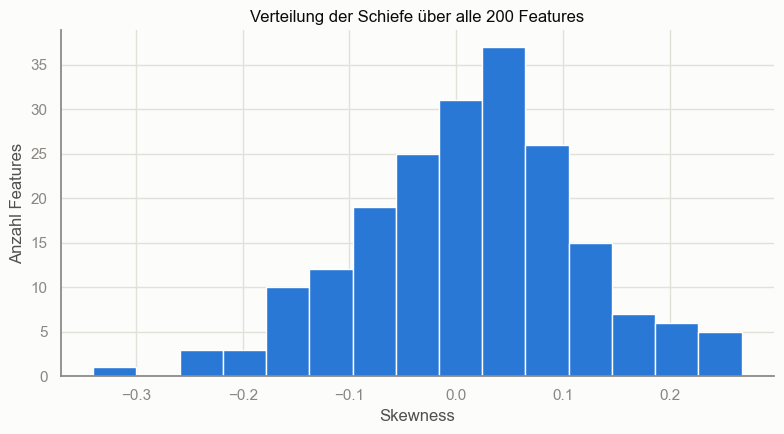

In [7]:
plt.figure(figsize=(8, 4.5))
df[feature_columns].skew().plot(kind="hist", bins=15, color=CATEGORICAL[0])
plt.title("Verteilung der Schiefe über alle 200 Features")
plt.xlabel("Skewness")
plt.ylabel("Anzahl Features")
plt.tight_layout()
plt.show()

**Information:** Die Schiefe liegt für die weit überwiegende Mehrheit der Features nahe 0 —
symmetrische, annähernd normalverteilte Formen dominieren. Nur wenige Features weichen
spürbar ab, keines davon extrem. Das bestätigt für den gesamten Datensatz (nicht nur die
oben gezeigten ersten 10 Features), dass Mittelwert-basierte Kennzahlen wie Cohen's d weiter
unten nicht durch systematische Schiefe verzerrt werden.

## Datenqualität

In [8]:
n_missing = int(df.isna().sum().sum())
n_duplicate_rows = int(df.duplicated().sum())
n_nonfinite = int((~np.isfinite(df[feature_columns].to_numpy(dtype=float))).sum())
n_constant_features = int((df[feature_columns].max() - df[feature_columns].min() == 0).sum())

print(f"Fehlende Werte:       {n_missing}")
print(f"Duplizierte Zeilen:   {n_duplicate_rows}")
print(f"Nicht-finite Werte:   {n_nonfinite}")
print(f"Konstante Features:   {n_constant_features}")

Fehlende Werte:       0
Duplizierte Zeilen:   0
Nicht-finite Werte:   0
Konstante Features:   0


## Zielvariable

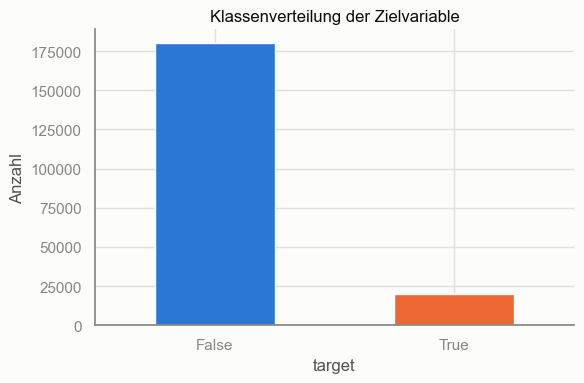

Klassenverhältnis (False : True): 9.0 : 1


In [9]:
class_counts = df["target"].value_counts()
imbalance_ratio = class_counts[False] / class_counts[True]

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=CATEGORICAL[:2])
plt.title("Klassenverteilung der Zielvariable")
plt.xlabel("target")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Klassenverhältnis (False : True): {imbalance_ratio:.1f} : 1")

**Information:** Die Zielvariable ist stark unausgeglichen — auf jede `target=True`-Zeile
kommen etwa 9 `target=False`-Zeilen. Das schließt Accuracy als alleinige Bewertungsmetrik für
spätere Modelle aus (ein Modell, das immer `False` vorhersagt, läge bereits bei ~90 %
Accuracy) und macht eine klassensensitive Metrik wie AUC-ROC notwendig.

## Kardinalität und Konzentration

Da die Features anonymisiert sind, wird geprüft, ob einzelne Variablen diskret oder
stark auf einzelne Werte konzentriert wirken.

In [10]:
concentration = pd.DataFrame({
    "unique_values": df[feature_columns].nunique(),
    "unique_share_percent": df[feature_columns].nunique() / len(df) * 100,
    "dominant_value_share_percent": [
        df[col].value_counts(normalize=True).iloc[0] * 100 for col in feature_columns
    ],
    "negative_share_percent": (df[feature_columns] < 0).mean() * 100,
})

concentration.sort_values("unique_values").head(10).round(3)

,unique_values,unique_share_percent,dominant_value_share_percent,negative_share_percent
var_68,451,0.226,0.542,0.000
var_91,7962,3.981,0.033,0.000
var_108,8525,4.262,0.156,0.000
var_103,9376,4.688,0.030,0.000
var_12,9561,4.780,0.102,0.000
var_148,10608,5.304,0.030,0.000
var_161,11071,5.536,0.026,0.000
var_71,13527,6.764,0.027,0.186
var_25,14853,7.426,0.020,0.000
var_43,15188,7.594,0.020,0.000


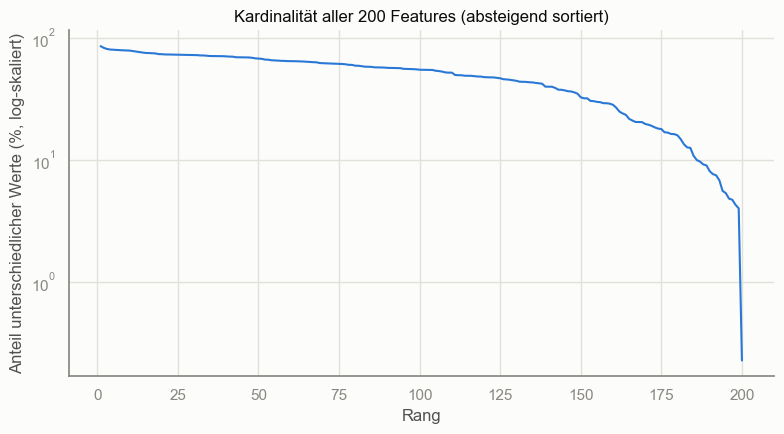

In [11]:
sorted_unique_share = concentration["unique_share_percent"].sort_values(ascending=False).to_numpy()

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(sorted_unique_share) + 1), sorted_unique_share, color=CATEGORICAL[0])
plt.yscale("log")
plt.title("Kardinalität aller 200 Features (absteigend sortiert)")
plt.xlabel("Rang")
plt.ylabel("Anteil unterschiedlicher Werte (%, log-skaliert)")
plt.tight_layout()
plt.show()

**Information:** Alle 200 Features sind eindeutig kontinuierlich — mit einer klaren Ausnahme:
die Kardinalität bricht am rechten Rand des Rangs steil ein. Die wenigen quasi-diskreten
Features (`var_68` und die anderen aus der Tabelle oben) sind visuell klar von der breiten
Masse kontinuierlicher Features abgesetzt, statt nur eine Randnotiz in der Tabelle zu sein.

## Verteilungen der Features

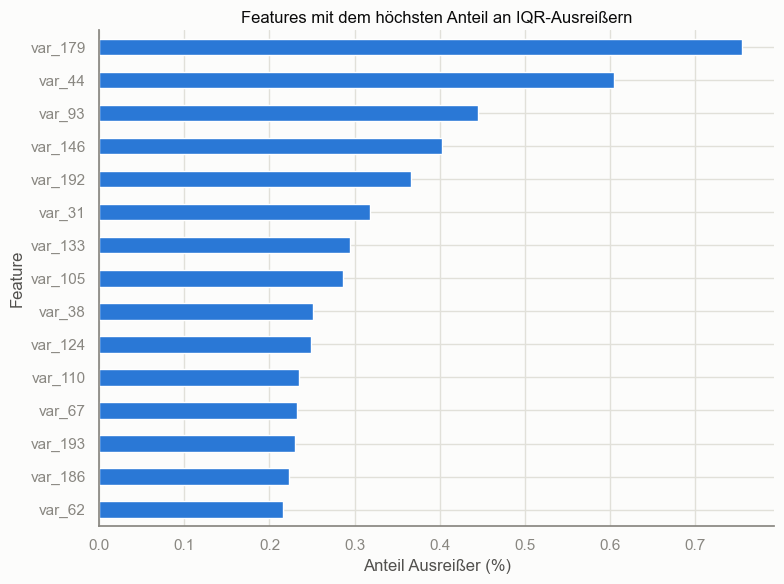

Median Ausreißeranteil über alle 200 Features: 0.02 %
Maximum: 0.75 % (var_179)


In [12]:
q1 = df[feature_columns].quantile(0.25)
q3 = df[feature_columns].quantile(0.75)
iqr = q3 - q1
outlier_mask = df[feature_columns].lt(q1 - 1.5 * iqr) | df[feature_columns].gt(q3 + 1.5 * iqr)
outlier_share = (outlier_mask.mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
outlier_share.head(15).sort_values().plot(kind="barh", color=CATEGORICAL[0])
plt.title("Features mit dem höchsten Anteil an IQR-Ausreißern")
plt.xlabel("Anteil Ausreißer (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(f"Median Ausreißeranteil über alle 200 Features: {outlier_share.median():.2f} %")
print(f"Maximum: {outlier_share.max():.2f} % ({outlier_share.idxmax()})")

**Information:** Der IQR-Ausreißeranteil ist über fast alle Features vernachlässigbar (Median
0,02 % über alle 200 Features), selbst das am stärksten betroffene Feature (`var_179`) liegt
nur bei 0,75 %. Für die Modellierung heißt das: eine robuste Skalierung wegen Ausreißern ist
hier nicht notwendig, Standardisierung reicht aus. Die Boxplots unten zeigen deshalb bewusst
die 6 Features mit dem höchsten Ausreißeranteil, nicht beliebige — sonst wäre kaum ein
Ausreißerpunkt zu sehen gewesen.

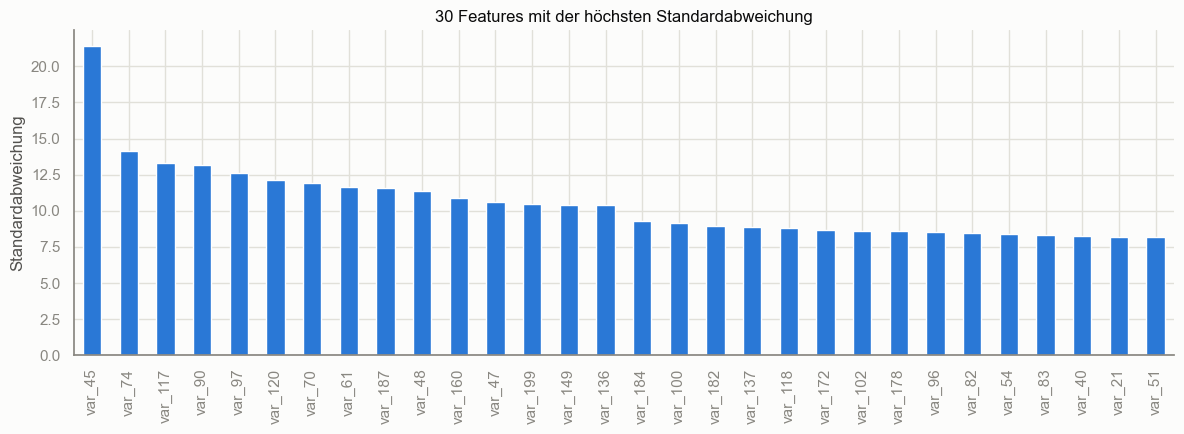

Überschneidung mit den 30 Features mit dem höchsten Ausreißeranteil: 4 von 30


In [13]:
top_std_features = df[feature_columns].std().sort_values(ascending=False).head(30)

plt.figure(figsize=(12, 4.5))
top_std_features.plot(kind="bar", color=CATEGORICAL[0])
plt.title("30 Features mit der höchsten Standardabweichung")
plt.ylabel("Standardabweichung")
plt.tight_layout()
plt.show()

overlap = set(top_std_features.index) & set(outlier_share.head(30).index)
print(f"Überschneidung mit den 30 Features mit dem höchsten Ausreißeranteil: {len(overlap)} von 30")

**Information:** Nur 4 der 30 streuungsstärksten Features tauchen auch unter den 30
Features mit dem höchsten Ausreißeranteil auf. Die hohe Standardabweichung ist bei diesem
Datensatz also überwiegend **nicht** durch wenige Ausreißerpunkte getrieben, sondern durch
tatsächlich breit gestreute, aber unauffällige Verteilungen — zwei unterschiedliche
Phänomene, die man sonst leicht verwechseln könnte.

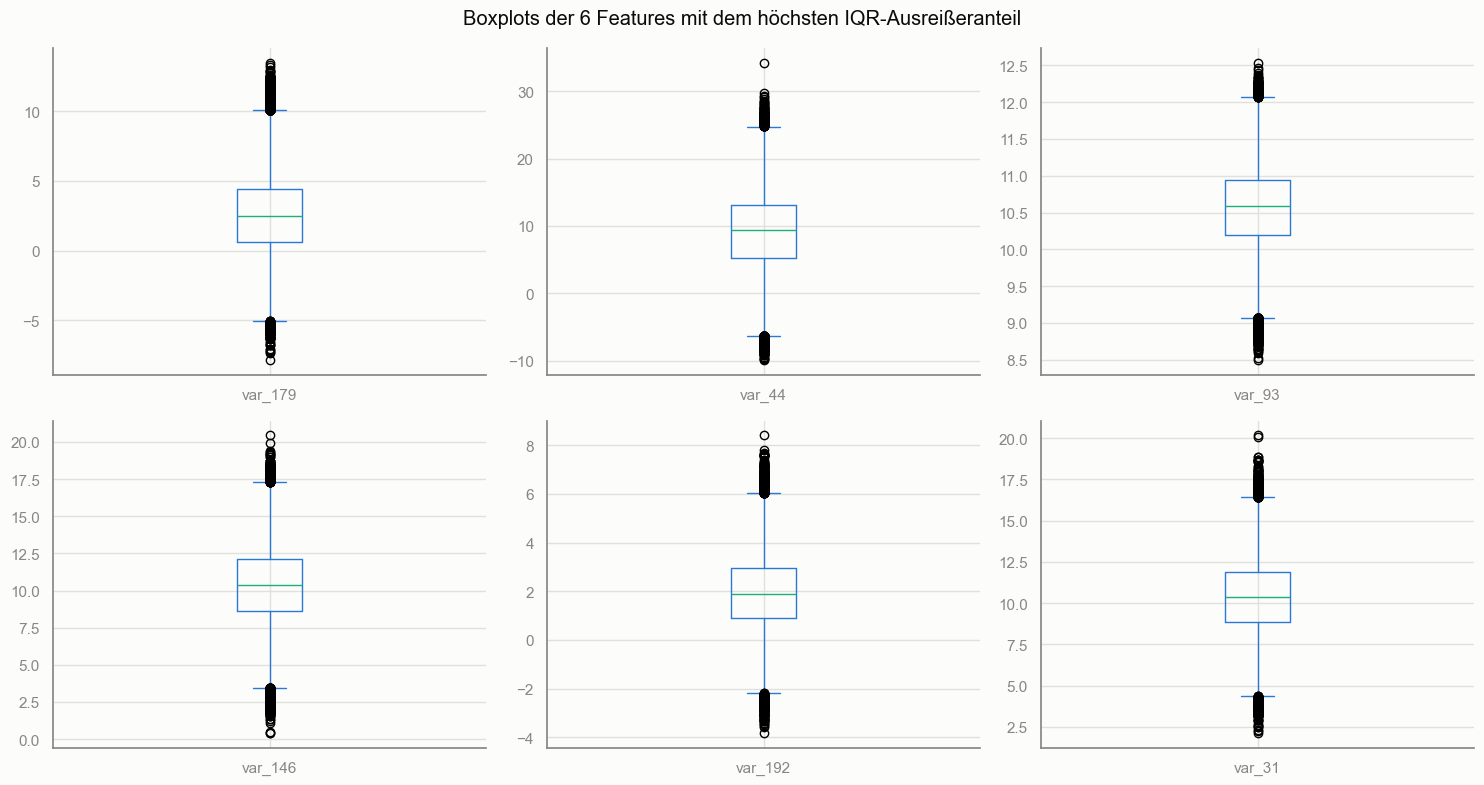

In [14]:
boxplot_features = outlier_share.head(6).index

df[boxplot_features].plot(
    kind="box", subplots=True, layout=(2, 3), figsize=(15, 8), sharex=False, sharey=False
)
plt.suptitle("Boxplots der 6 Features mit dem höchsten IQR-Ausreißeranteil")
plt.tight_layout()
plt.show()

**Information:** Selbst bei den 6 Features mit dem höchsten IQR-Ausreißeranteil (bis 0,75 %)
sind einzelne Ausreißerpunkte sichtbar, aber nicht extrem — konsistent mit dem insgesamt
vernachlässigbaren Ausreißeranteil. Die Features unterscheiden sich zudem deutlich in Lage
und Streuung, ein Hinweis, dass sie vor einem skalenabhängigen Modell (z. B. logistische
Regression) standardisiert werden müssen.

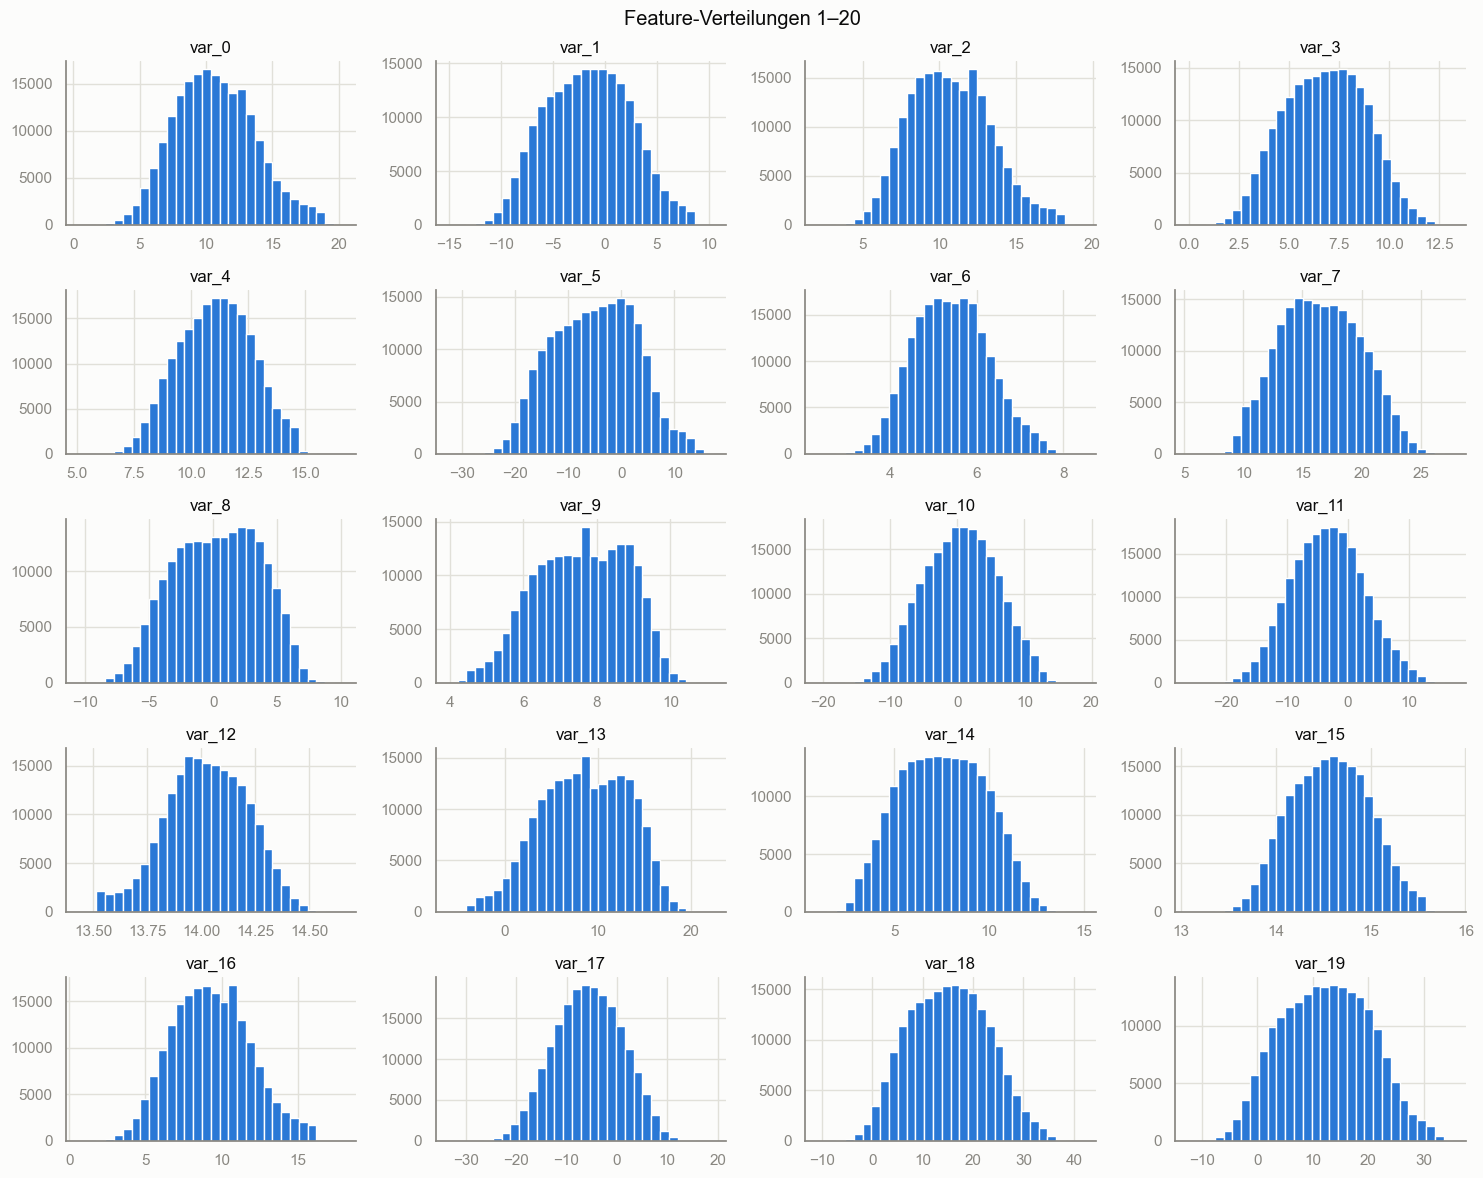

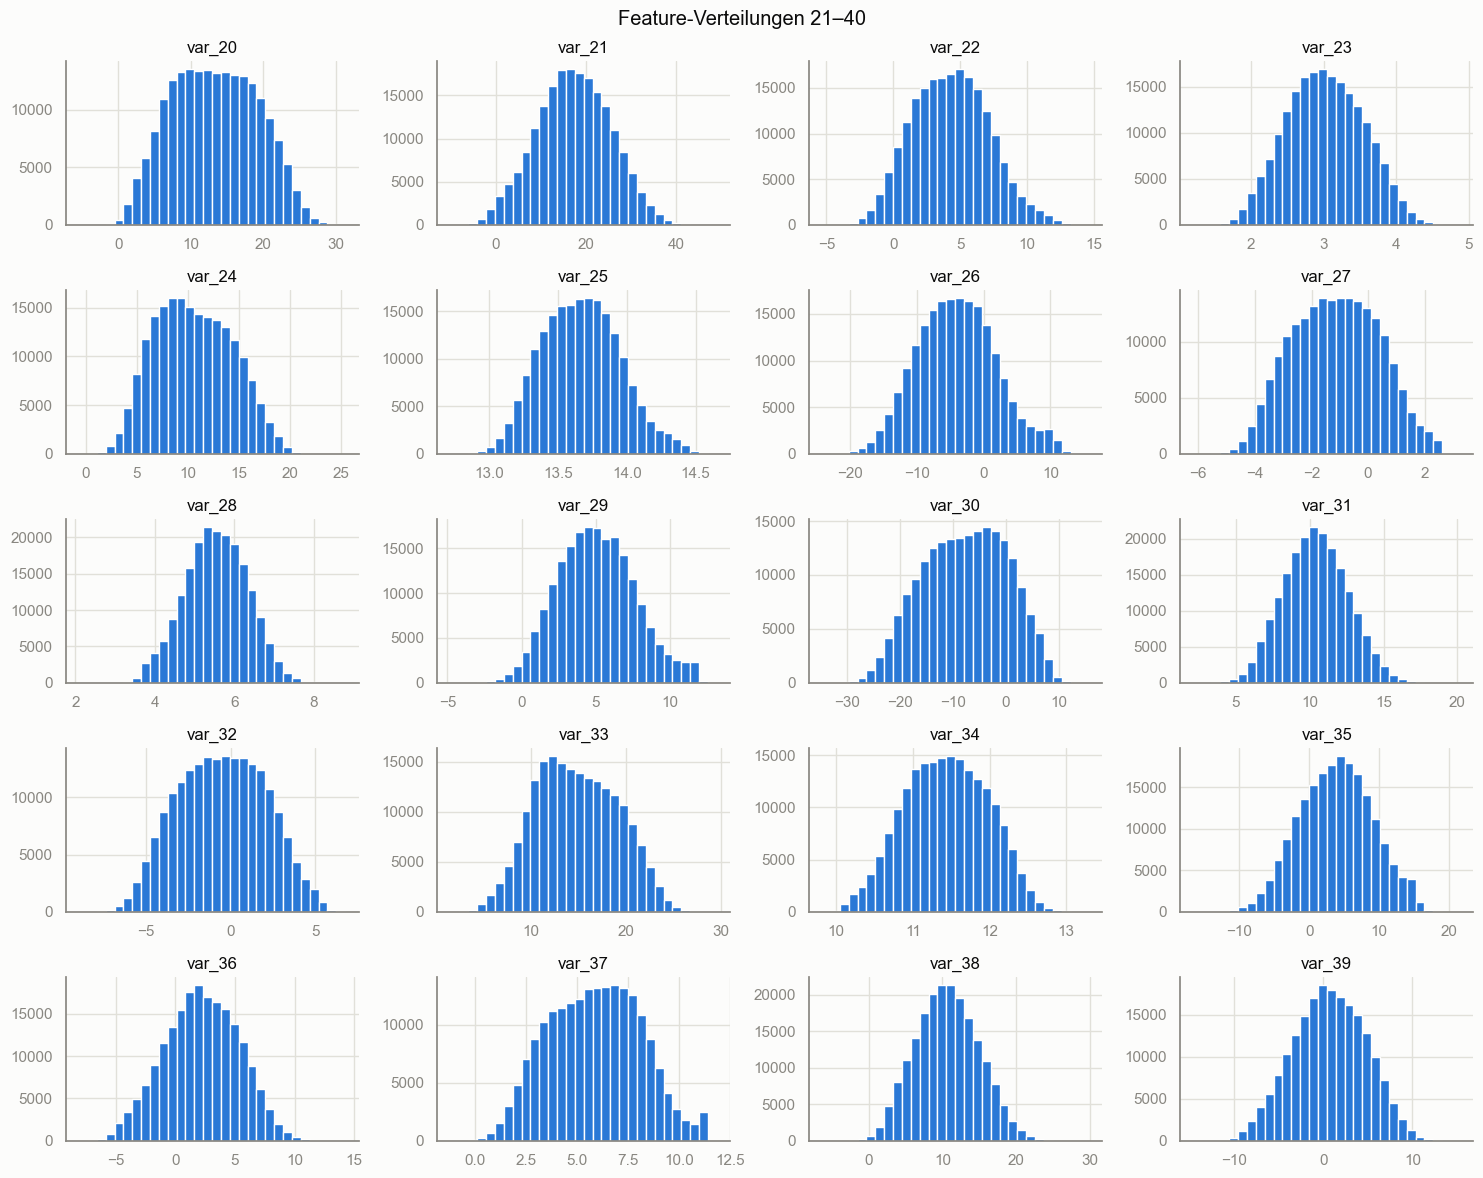

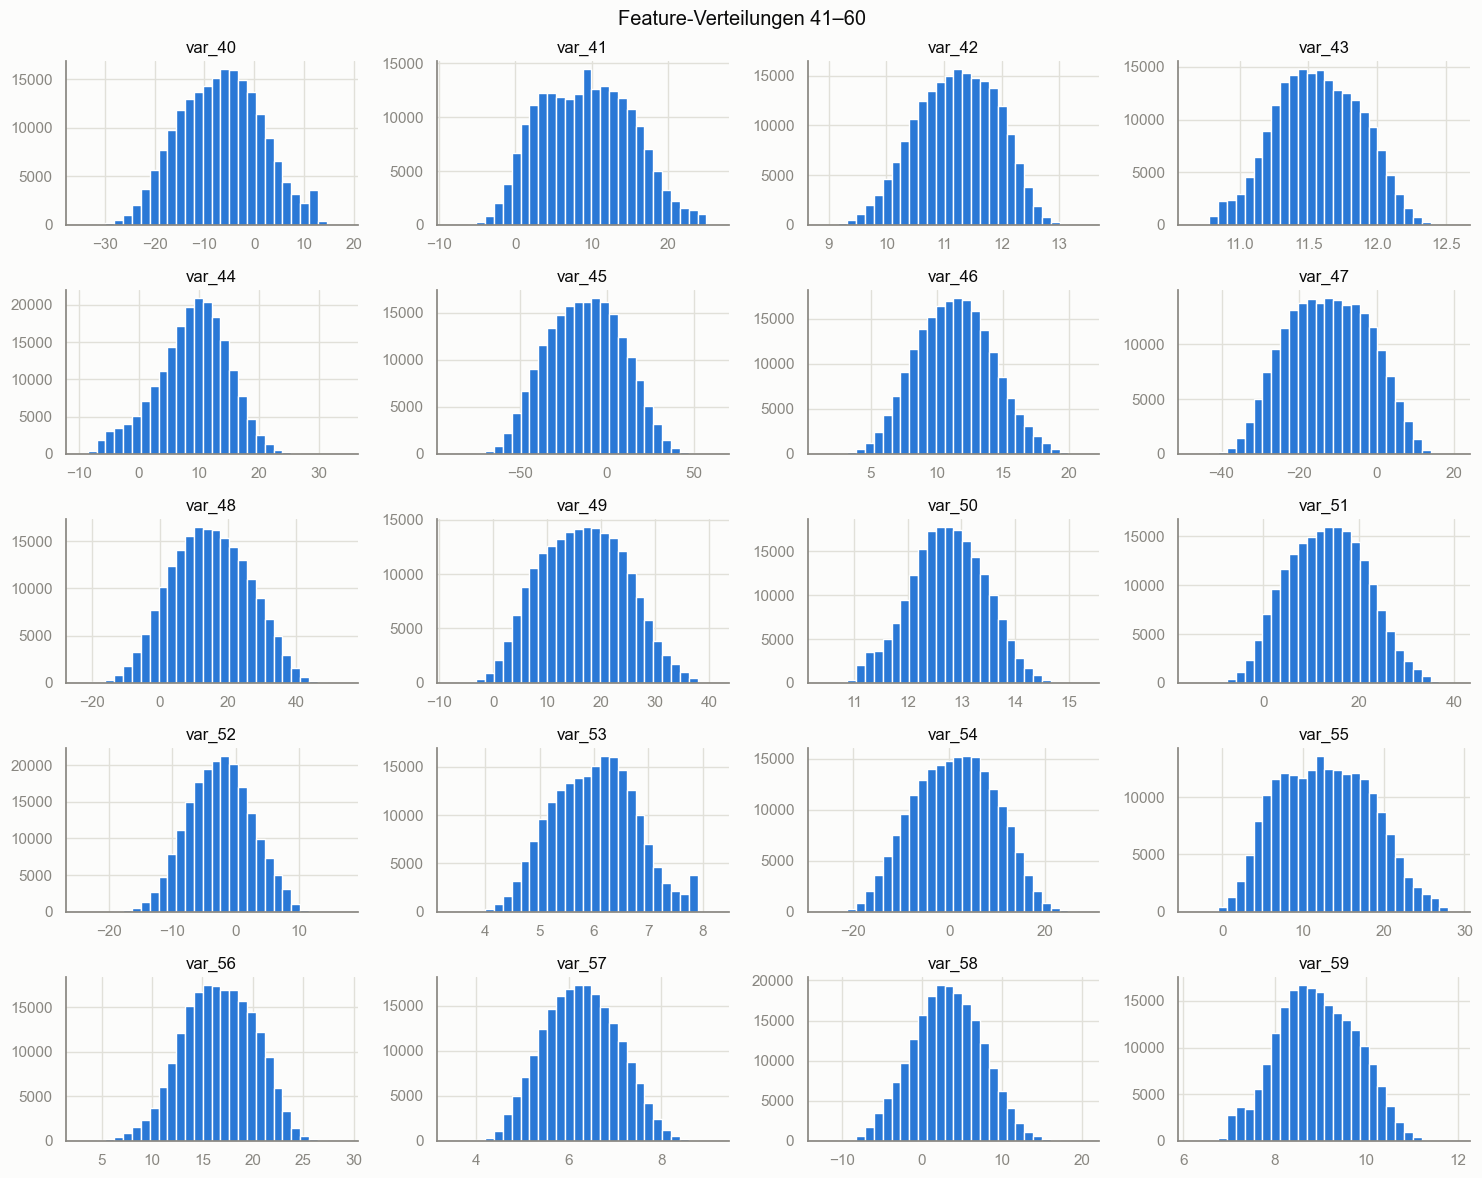

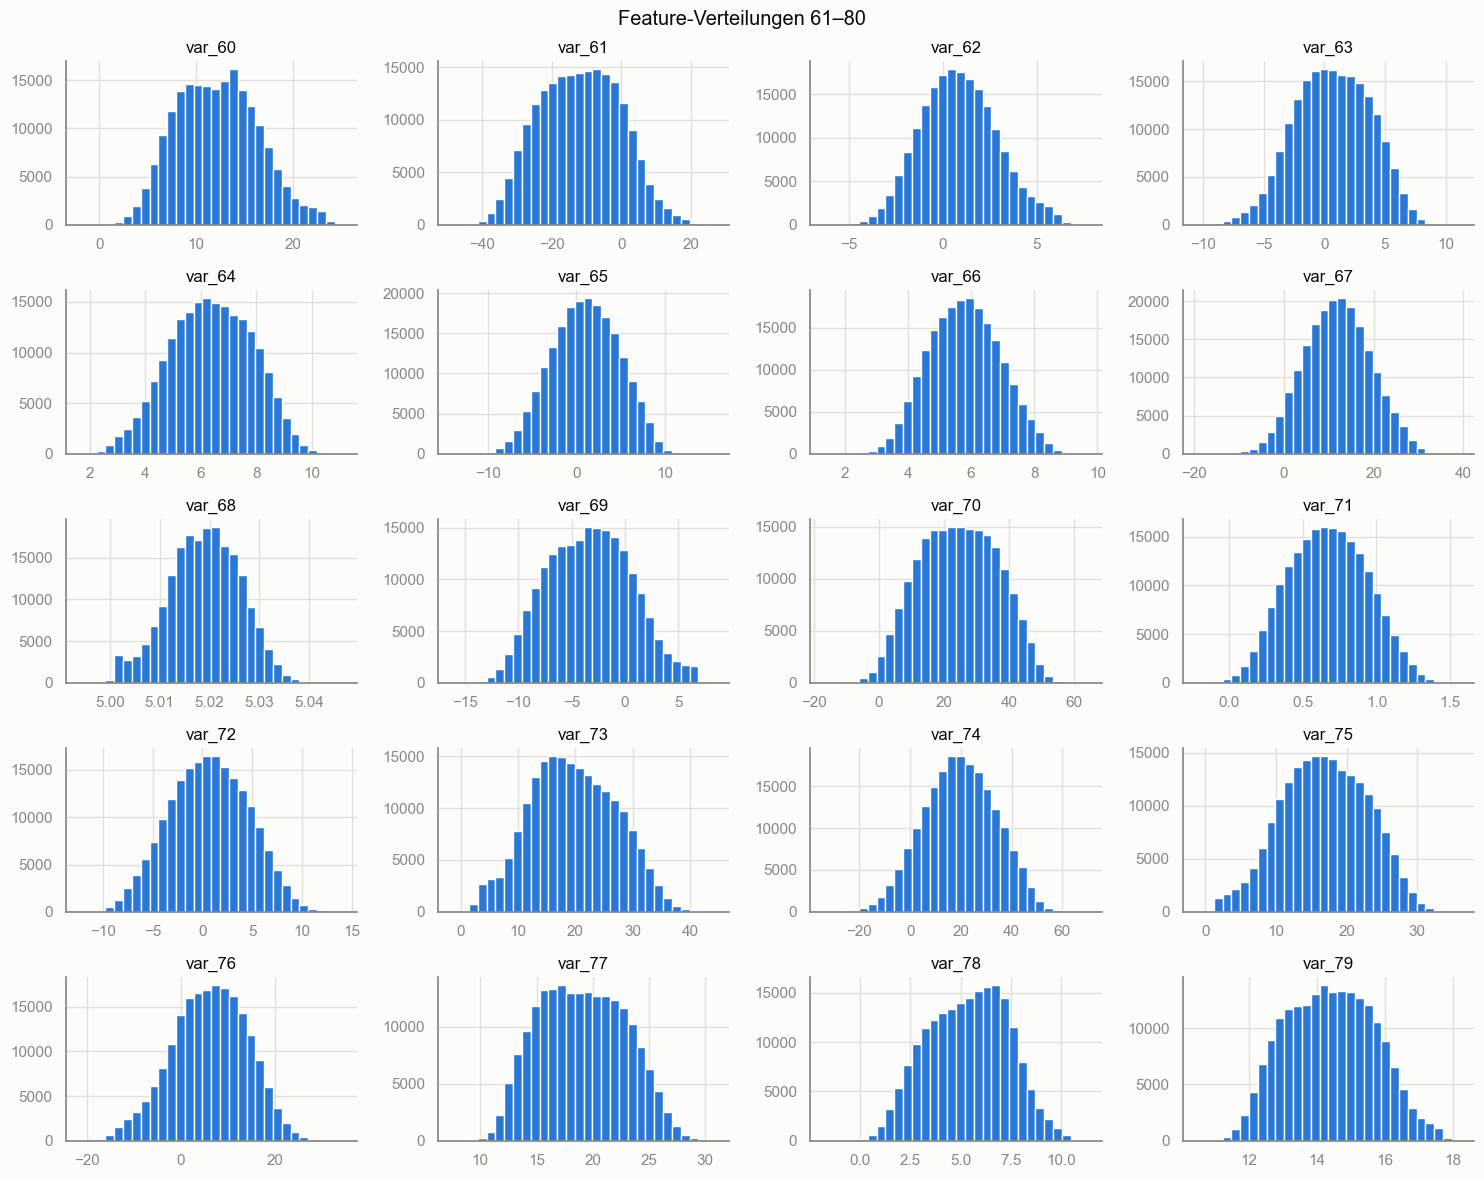

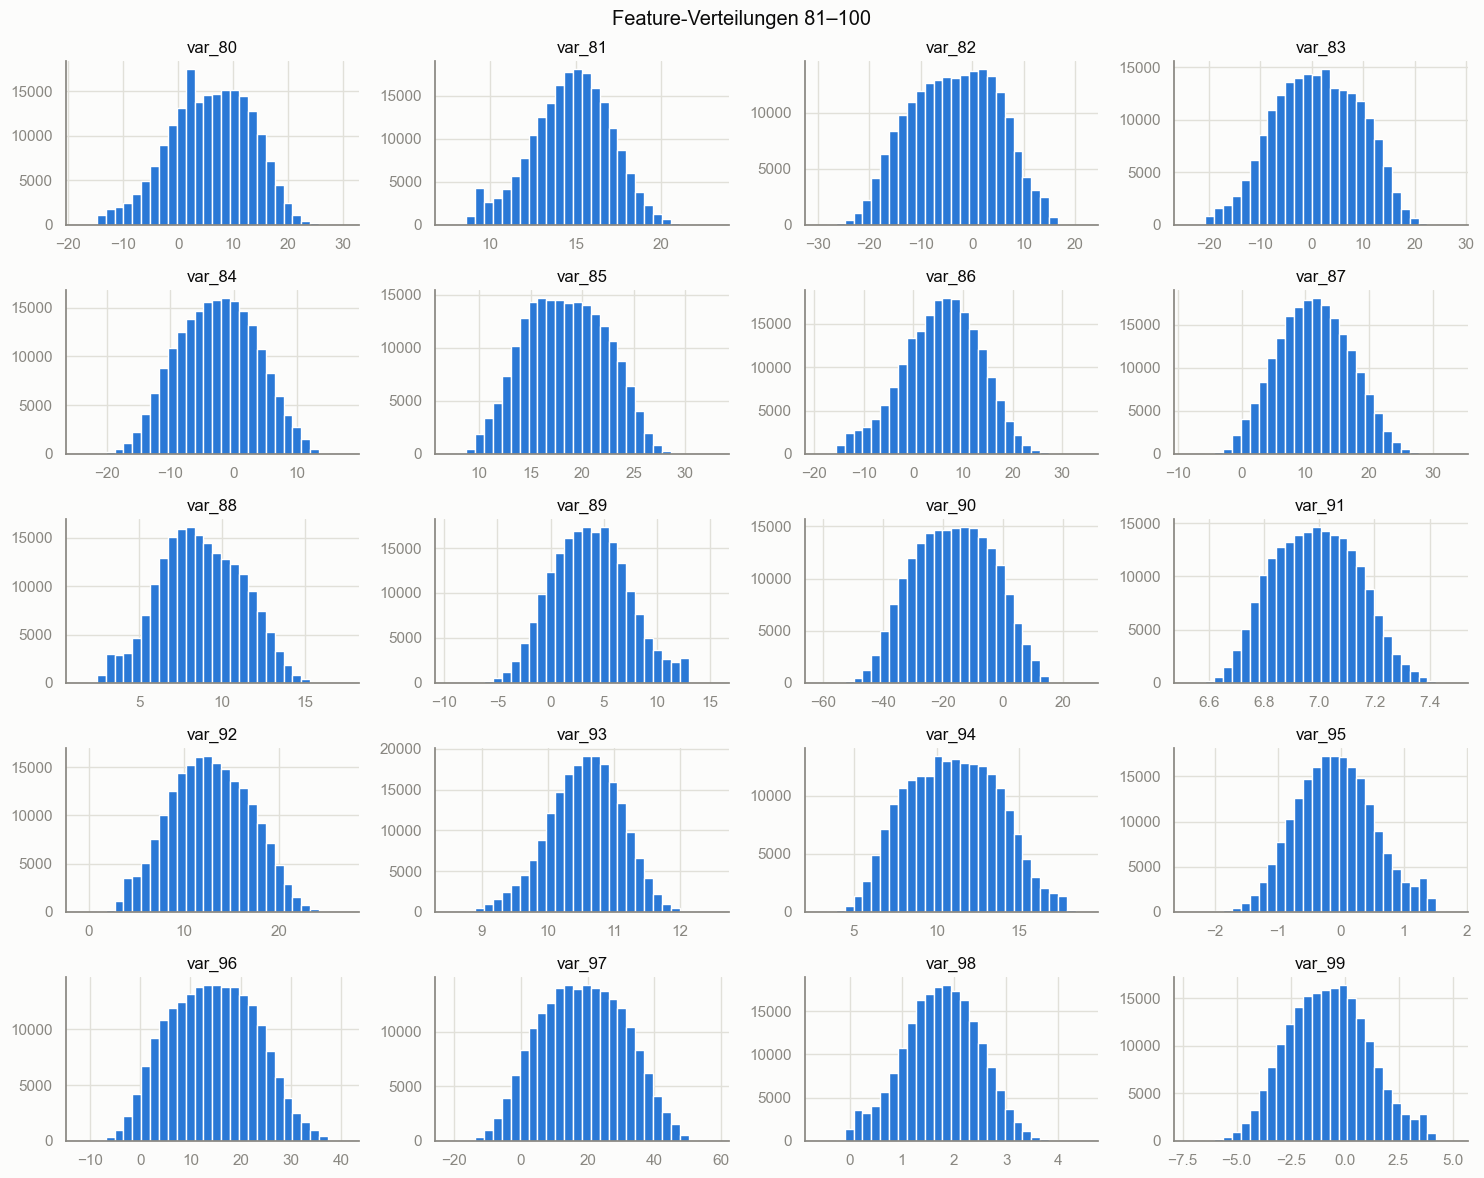

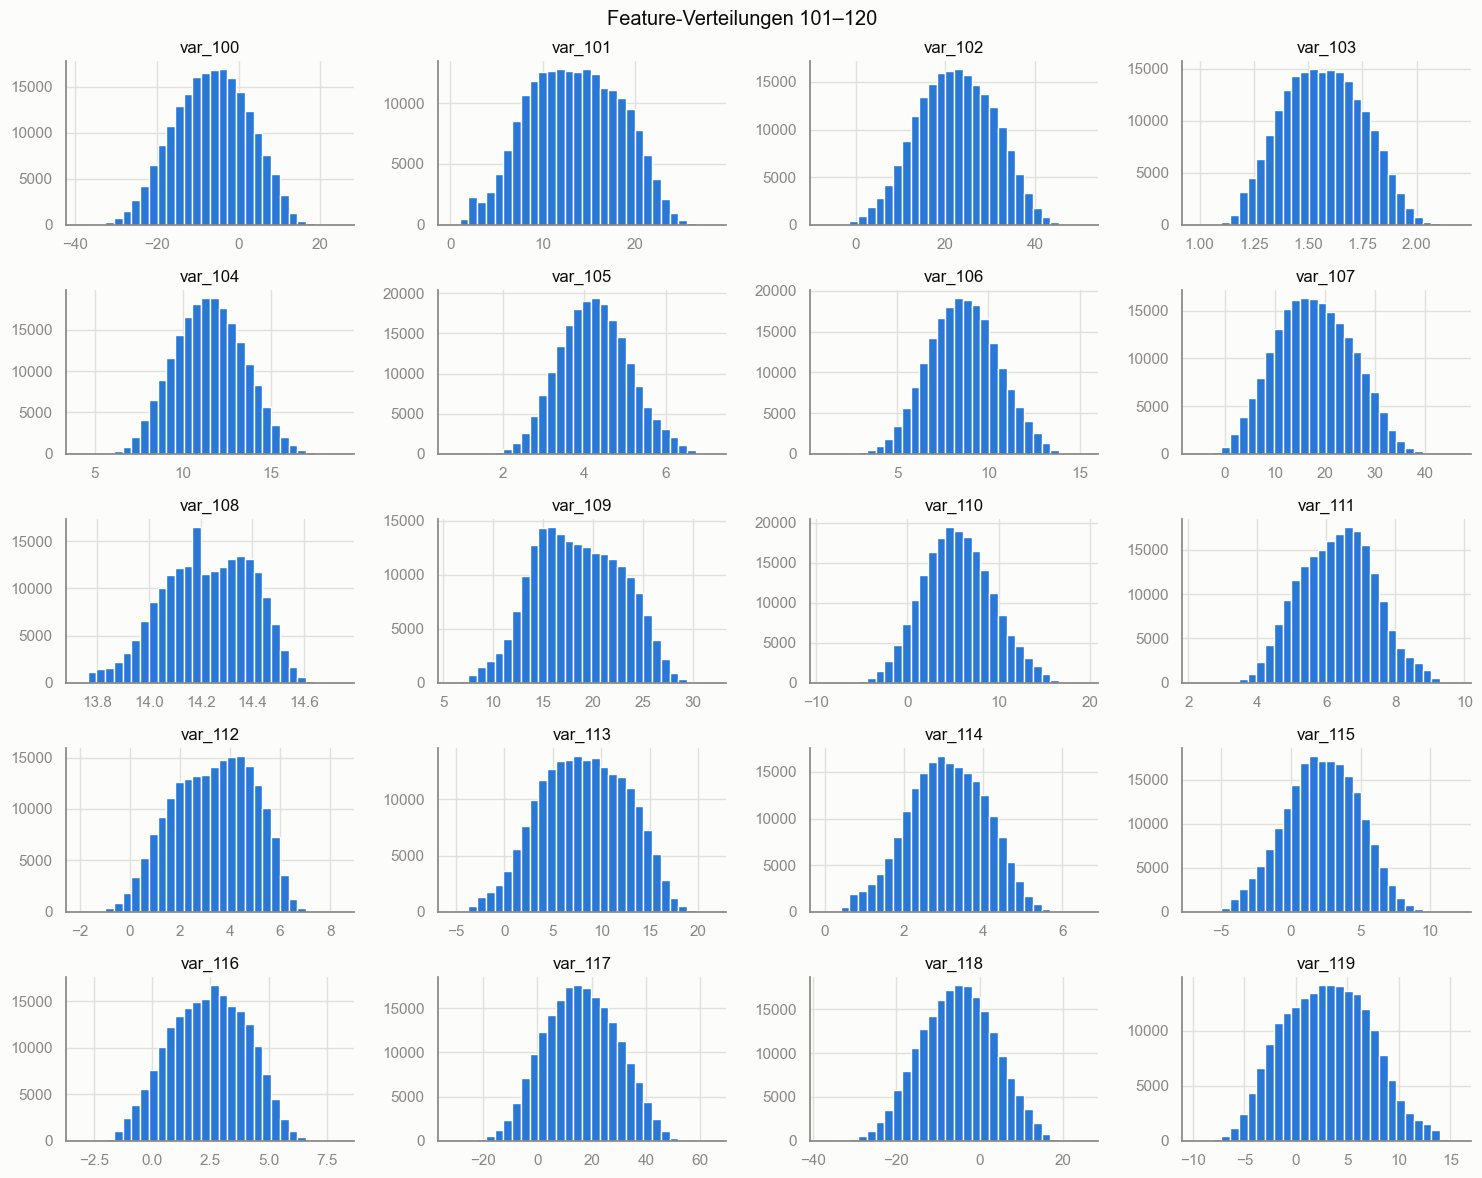

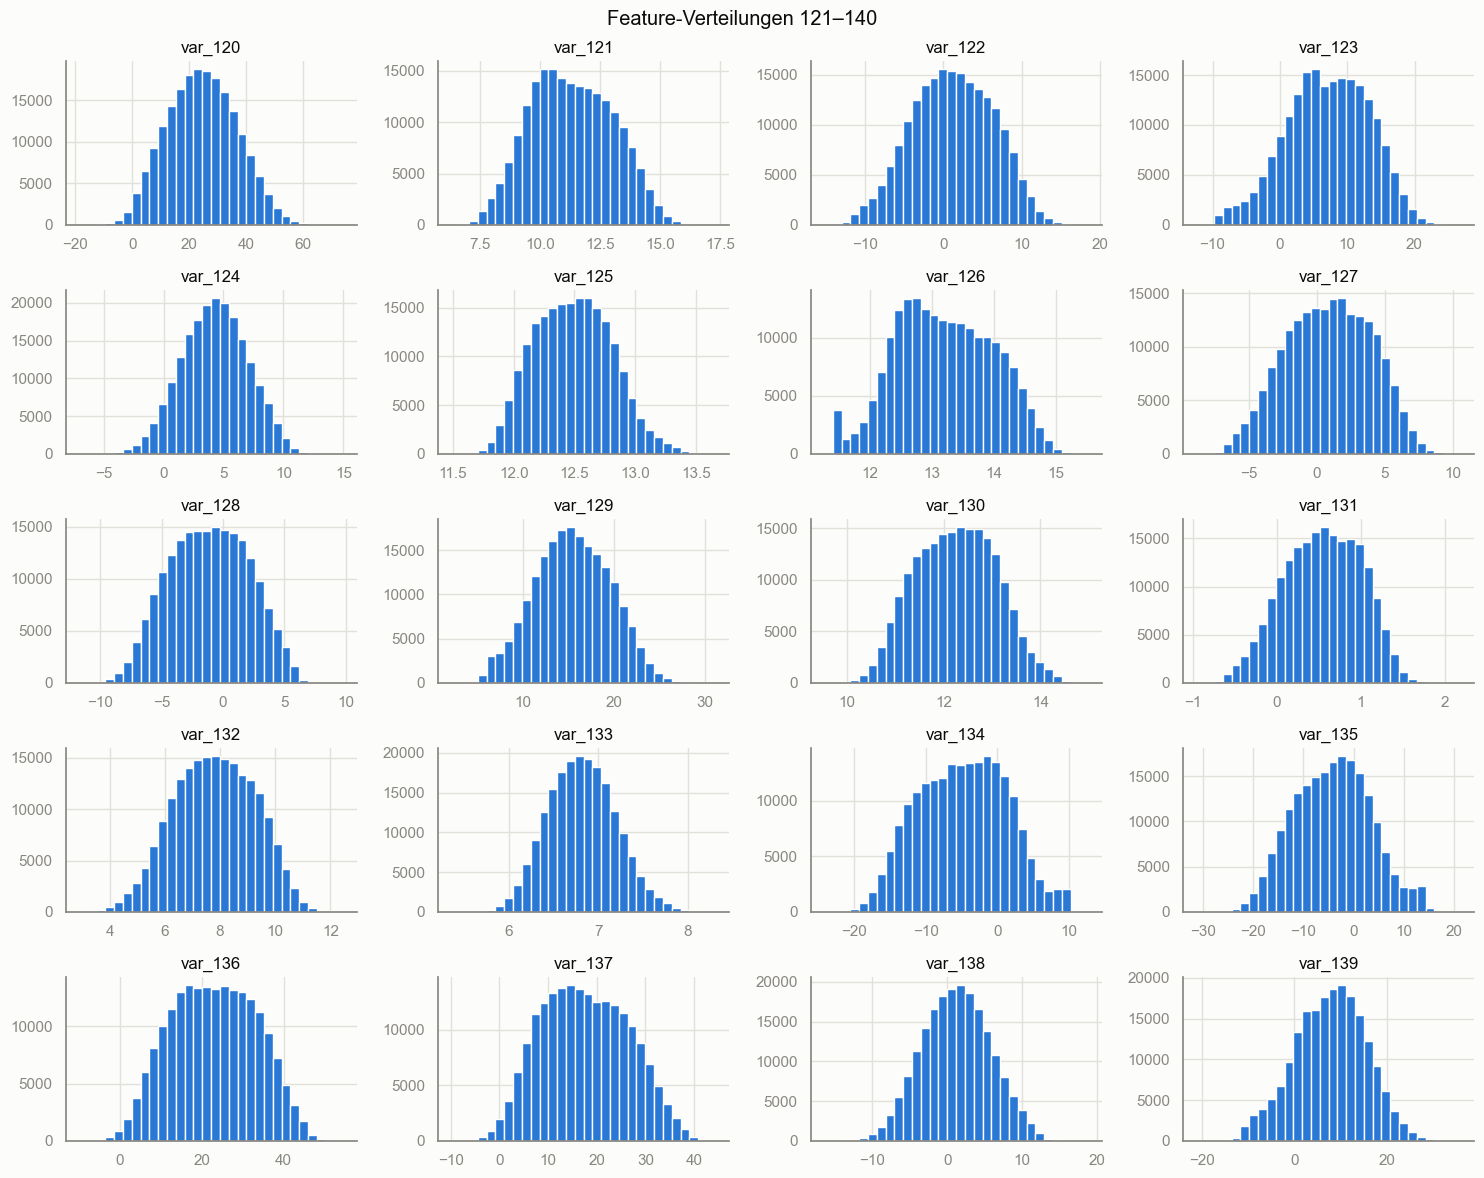

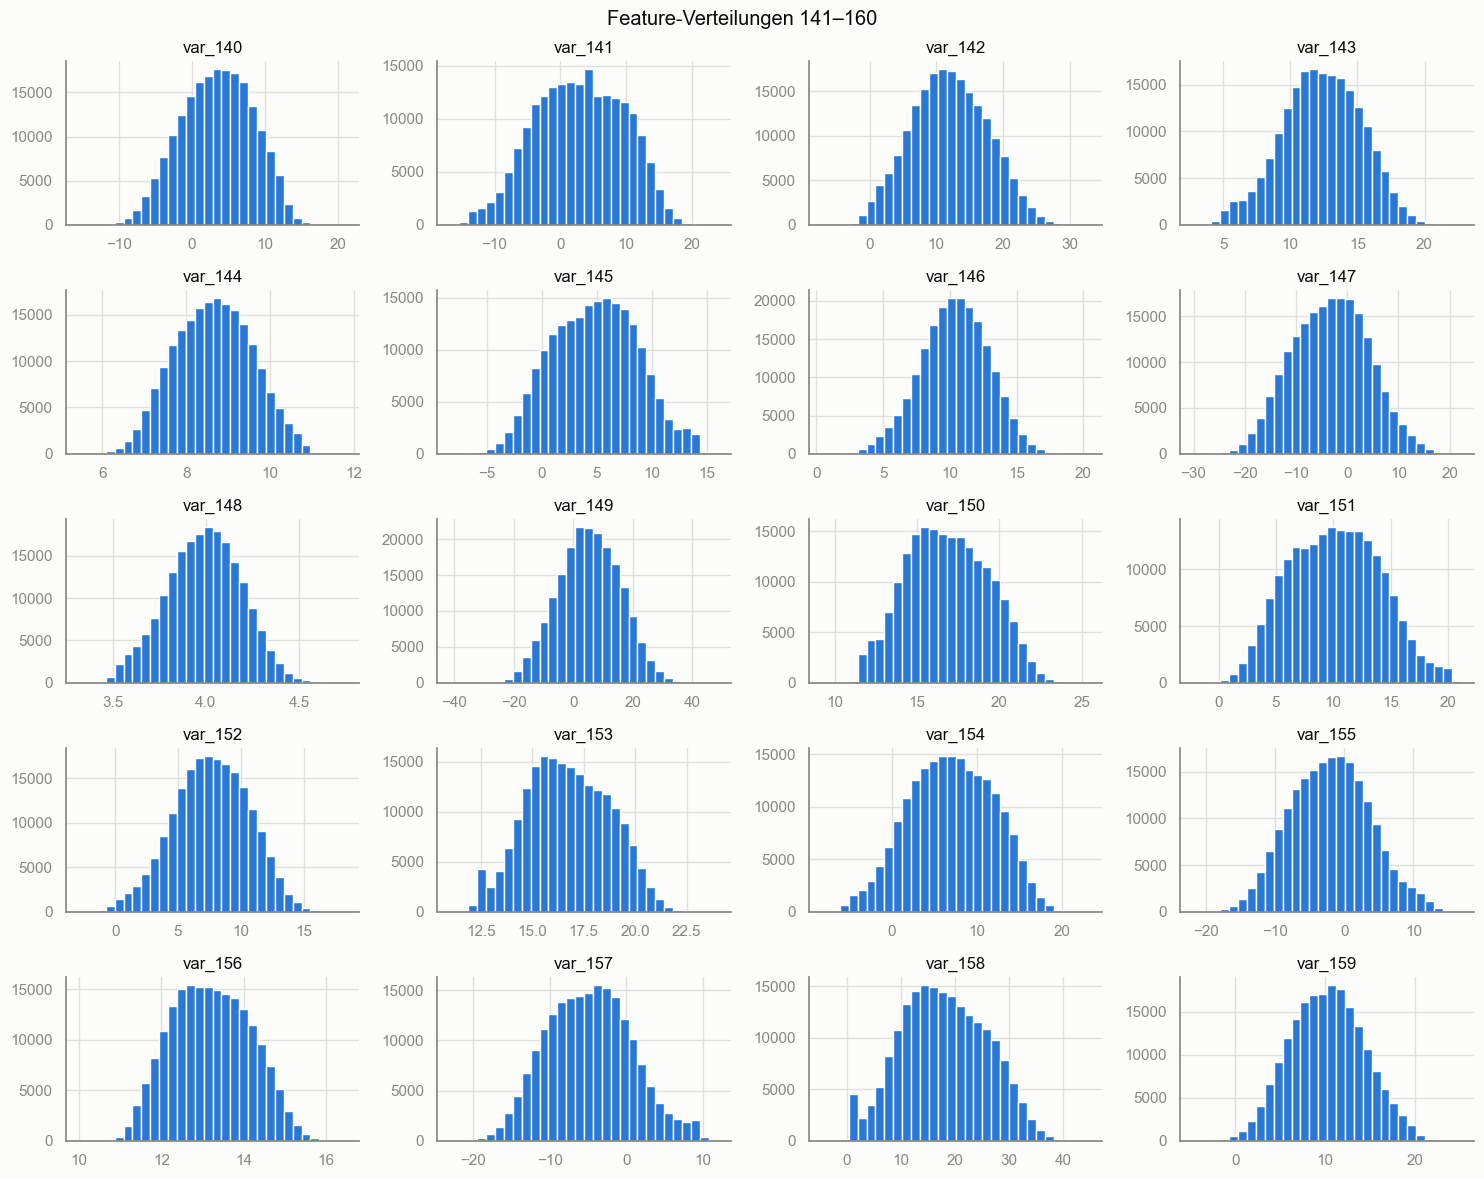

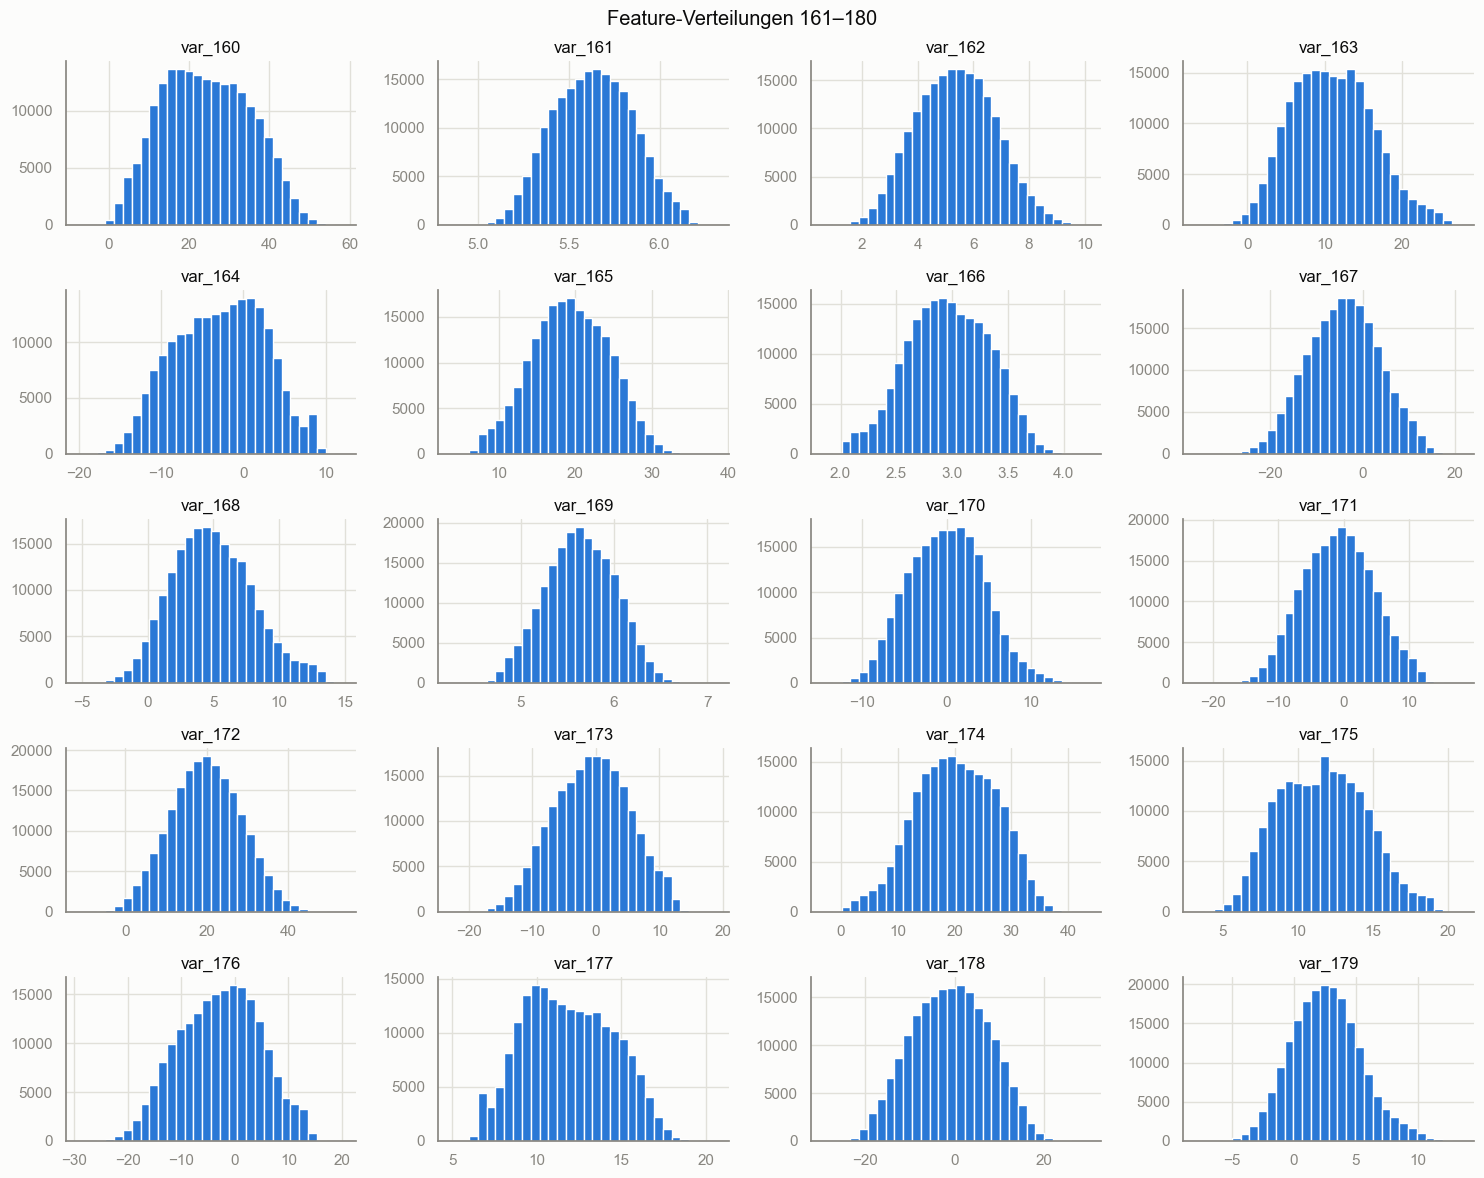

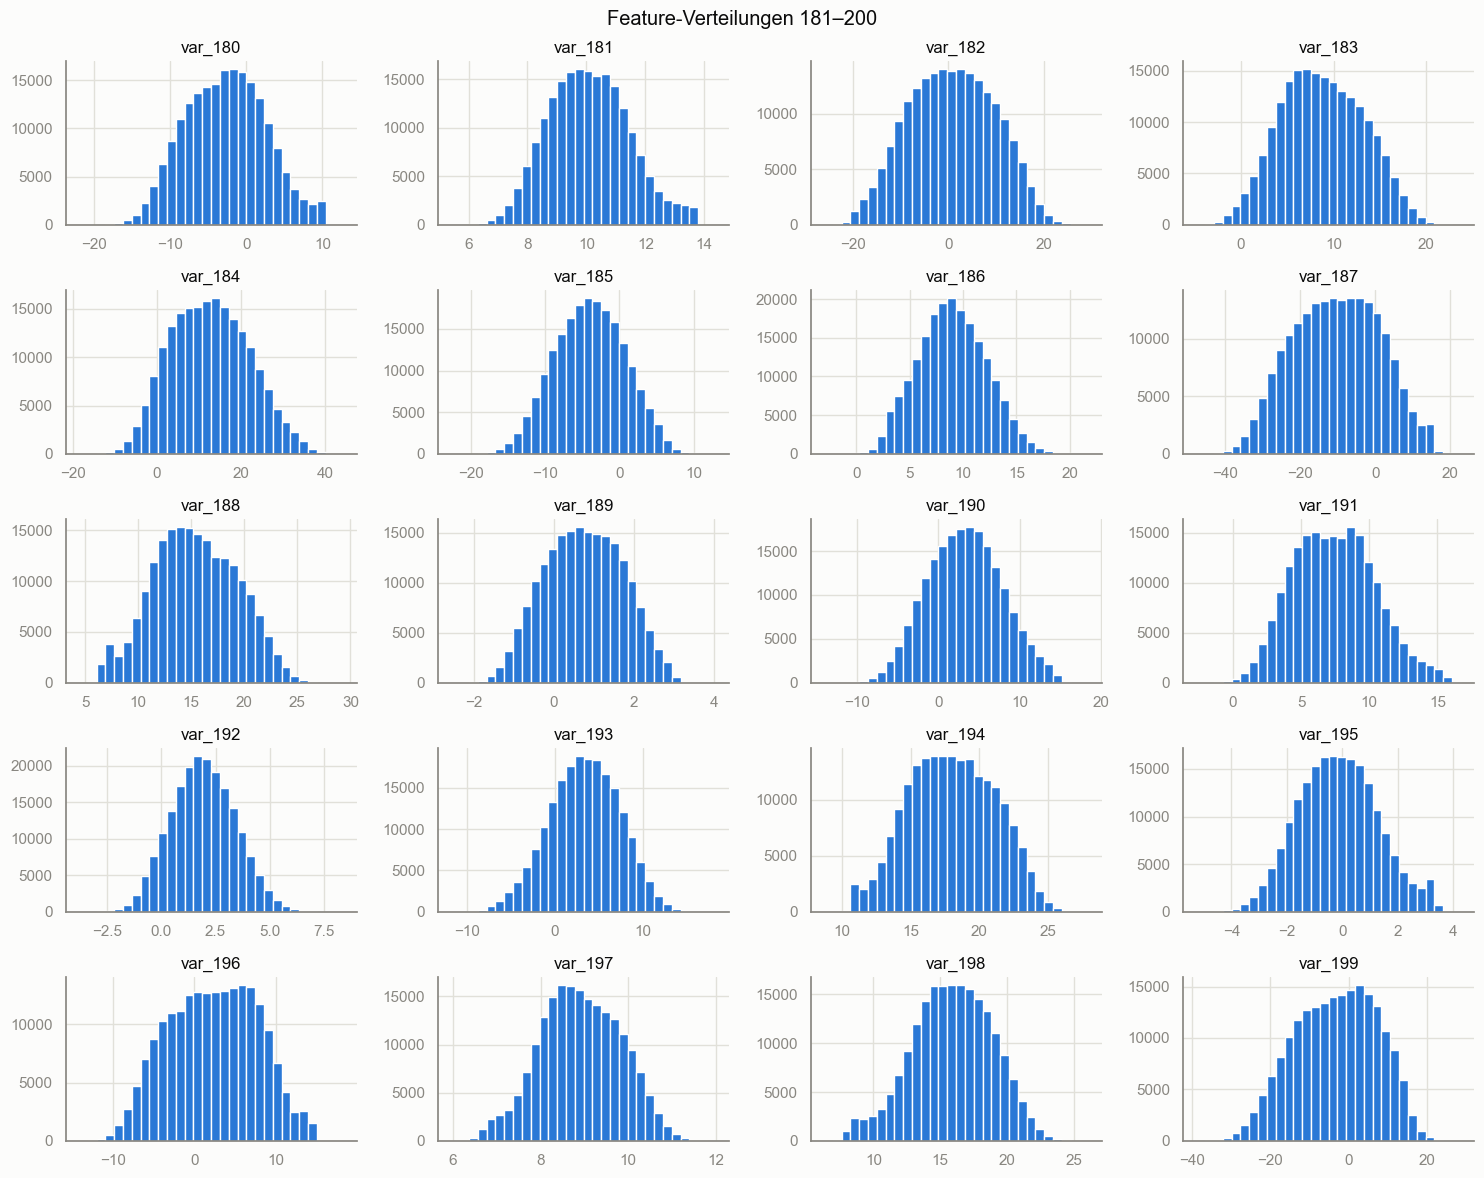

In [15]:
features_per_page = 20

for start in range(0, len(feature_columns), features_per_page):
    selected = feature_columns[start:start + features_per_page]
    df[selected].hist(bins=30, figsize=(15, 12), layout=(5, 4))
    plt.suptitle(f"Feature-Verteilungen {start + 1}–{min(start + features_per_page, len(feature_columns))}")
    plt.tight_layout()
    plt.show()

**Information:** Die Verteilungsformen reichen von annähernd normal bis spürbar schief; keine
Spalte wirkt offensichtlich diskret oder kategorial verkleidet (abgesehen von den weiter unten
identifizierten konzentrierten Ausnahmen wie `var_68`). Das bestätigt, dass alle `var_*`-Spalten
tatsächlich kontinuierlich sind und entsprechend behandelt werden können.

## Zusammenhang der Features mit der Zielvariable

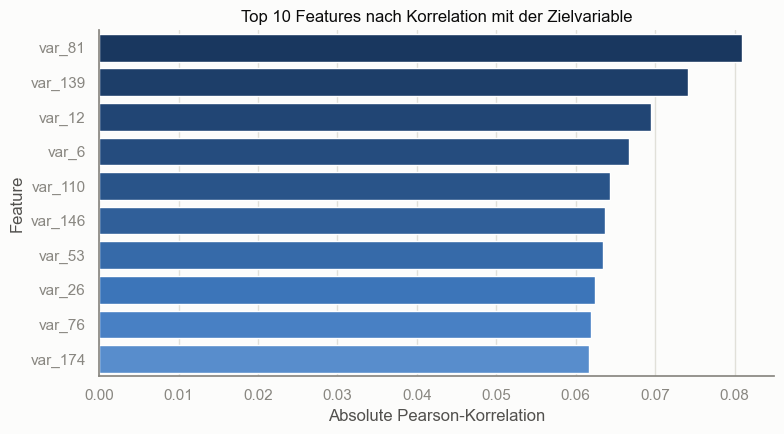

In [16]:
target_correlation = (
    df[feature_columns].corrwith(df["target"].astype(int)).abs().sort_values(ascending=False)
)
top_corr = target_correlation.head(10)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index,
            palette=list(SEQUENTIAL_BLUE(np.linspace(0.4, 1, 10))[::-1]), legend=False)
plt.title("Top 10 Features nach Korrelation mit der Zielvariable")
plt.xlabel("Absolute Pearson-Korrelation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Information:** Selbst das am stärksten korrelierte Feature erreicht nur eine moderate
Korrelation mit `target` (Größenordnung vergleichbar mit den Cohen's-d-Werten weiter unten) —
es gibt kein dominantes Einzelmerkmal, das die Klassifikation allein erklären könnte.

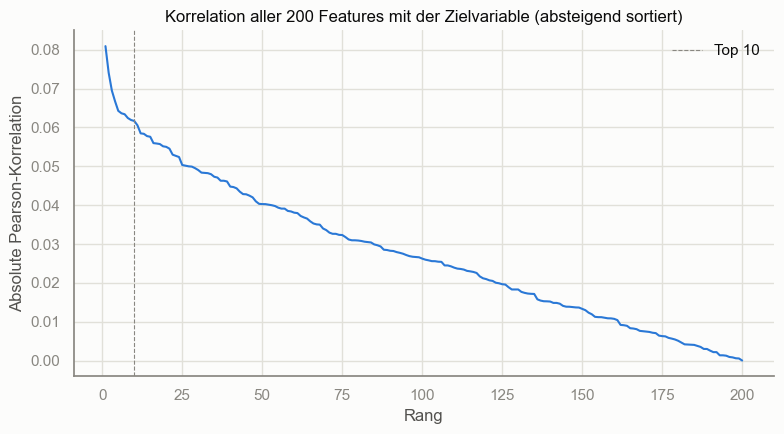

Median: 0.0261
95. Perzentil: 0.0606
Maximum: 0.0809


In [17]:
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(target_correlation) + 1), target_correlation.to_numpy(), color=CATEGORICAL[0])
plt.axvline(10, color=INK_MUTED, linewidth=0.8, linestyle="--", label="Top 10")
plt.title("Korrelation aller 200 Features mit der Zielvariable (absteigend sortiert)")
plt.xlabel("Rang")
plt.ylabel("Absolute Pearson-Korrelation")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Median: {target_correlation.median():.4f}")
print(f"95. Perzentil: {target_correlation.quantile(0.95):.4f}")
print(f"Maximum: {target_correlation.max():.4f}")

**Information:** Die Top-10-Auswahl ist repräsentativ und keine willkürliche Spitze — nach dem
steilen Anfangsabfall bis etwa Rang 10 geht die Kurve in einen gleichmäßigen, kontinuierlichen
Rückgang über, statt auf einem Plateau zu verharren und dann abrupt zu brechen. Es gibt also
keinen versteckten zweiten "starken" Feature-Cluster außerhalb der Top 10, der hier fehlen
würde — nur einen einzigen zusammenhängenden Abwärtstrend von `var_81` bis zum schwächsten
Feature.

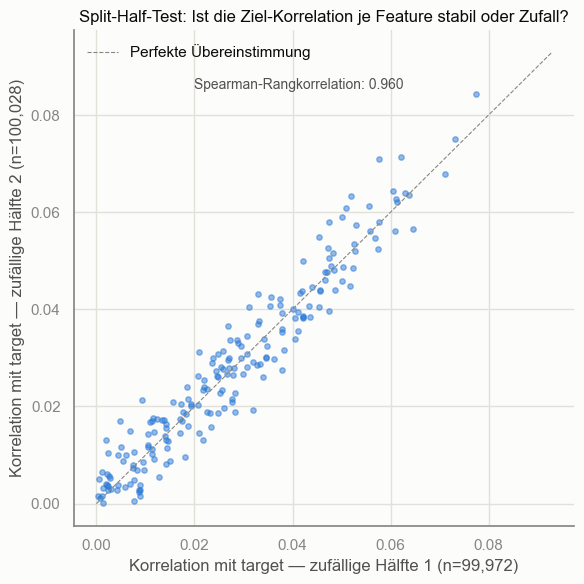

In [18]:
rng = np.random.default_rng(42)
half1_mask = rng.random(len(df)) < 0.5

corr_half1 = df.loc[half1_mask, feature_columns].corrwith(df.loc[half1_mask, "target"].astype(int)).abs()
corr_half2 = df.loc[~half1_mask, feature_columns].corrwith(df.loc[~half1_mask, "target"].astype(int)).abs()

rank_stability = corr_half1.corr(corr_half2, method="spearman")

plt.figure(figsize=(6, 6))
plt.scatter(corr_half1, corr_half2, alpha=0.5, s=15, color=CATEGORICAL[0])
plot_limit = max(corr_half1.max(), corr_half2.max()) * 1.1
plt.plot([0, plot_limit], [0, plot_limit], color=INK_MUTED, linewidth=0.8, linestyle="--",
         label="Perfekte Übereinstimmung")
plt.text(0.02, plot_limit * 0.92, f"Spearman-Rangkorrelation: {rank_stability:.3f}",
         fontsize=10, color=INK_SECONDARY)
plt.xlabel(f"Korrelation mit target — zufällige Hälfte 1 (n={int(half1_mask.sum()):,})")
plt.ylabel(f"Korrelation mit target — zufällige Hälfte 2 (n={int((~half1_mask).sum()):,})")
plt.title("Split-Half-Test: Ist die Ziel-Korrelation je Feature stabil oder Zufall?")
plt.legend()
plt.tight_layout()
plt.show()

**Information:** Die Punkte liegen fast exakt auf der Diagonale (Spearman-Rangkorrelation
0,960) — die Top-Feature-Rangfolge nach Korrelation mit `target` ist über zwei zufällige
Hälften des Datensatzes stabil, kein Stichproben-Zufallsartefakt.

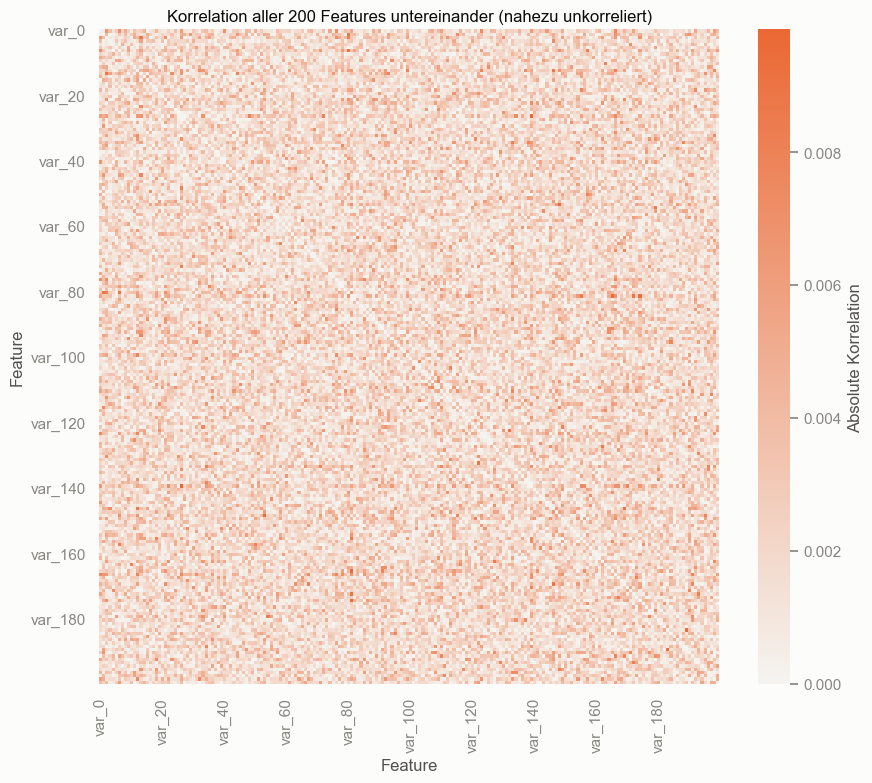

In [19]:
feature_corr = df[feature_columns].corr().abs()
feature_corr = feature_corr.mask(np.eye(len(feature_corr), dtype=bool), 0.0)

plt.figure(figsize=(9, 8))
sns.heatmap(feature_corr, cmap=SEQUENTIAL_ORANGE, vmin=0, vmax=feature_corr.to_numpy().max(),
            xticklabels=20, yticklabels=20, cbar_kws={"label": "Absolute Korrelation"})
plt.title("Korrelation aller 200 Features untereinander (nahezu unkorreliert)")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Information:** Die Korrelationen zwischen den Features liegen durchweg unter 0,05 (siehe
Farbskala) — die Features sind untereinander praktisch unabhängig. Das rechtfertigt
methodisch den Verzicht auf eine Multikollinearitäts-Behandlung (z. B. PCA zur
Redundanzreduktion) und begründet, warum Modelle, die Features unabhängig bewerten, hier
gut funktionieren sollten.

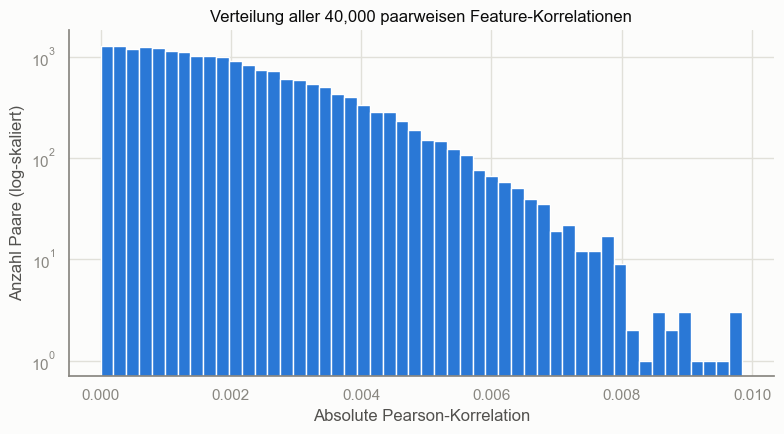

Maximum: 0.0098
99. Perzentil: 0.0064
Feature-Paare mit |r| >= 0.8: 0


In [20]:
correlation_matrix = df[feature_columns].corr().abs()
upper_triangle_mask = np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=1)
all_correlations = correlation_matrix.where(upper_triangle_mask).stack()

plt.figure(figsize=(8, 4.5))
plt.hist(all_correlations, bins=50, color=CATEGORICAL[0])
plt.title(f"Verteilung aller {len(all_correlations):,} paarweisen Feature-Korrelationen")
plt.xlabel("Absolute Pearson-Korrelation")
plt.ylabel("Anzahl Paare (log-skaliert)")
plt.yscale("log")
plt.tight_layout()
plt.show()

n_redundant_pairs = int((all_correlations >= 0.8).sum())
print(f"Maximum: {all_correlations.max():.4f}")
print(f"99. Perzentil: {all_correlations.quantile(0.99):.4f}")
print(f"Feature-Paare mit |r| >= 0.8: {n_redundant_pairs}")

**Information:** Die Heatmap zeigt bereits alle 200 Features, das Histogramm ergänzt die
Verteilungsform: die weit überwiegende Mehrheit der 19.900 Feature-Paare konzentriert sich
nahe 0, selbst das 99. Perzentil liegt noch deutlich unter dem, was man als relevante
Korrelation werten würde. Multikollinearität ist damit ausgeschlossen.

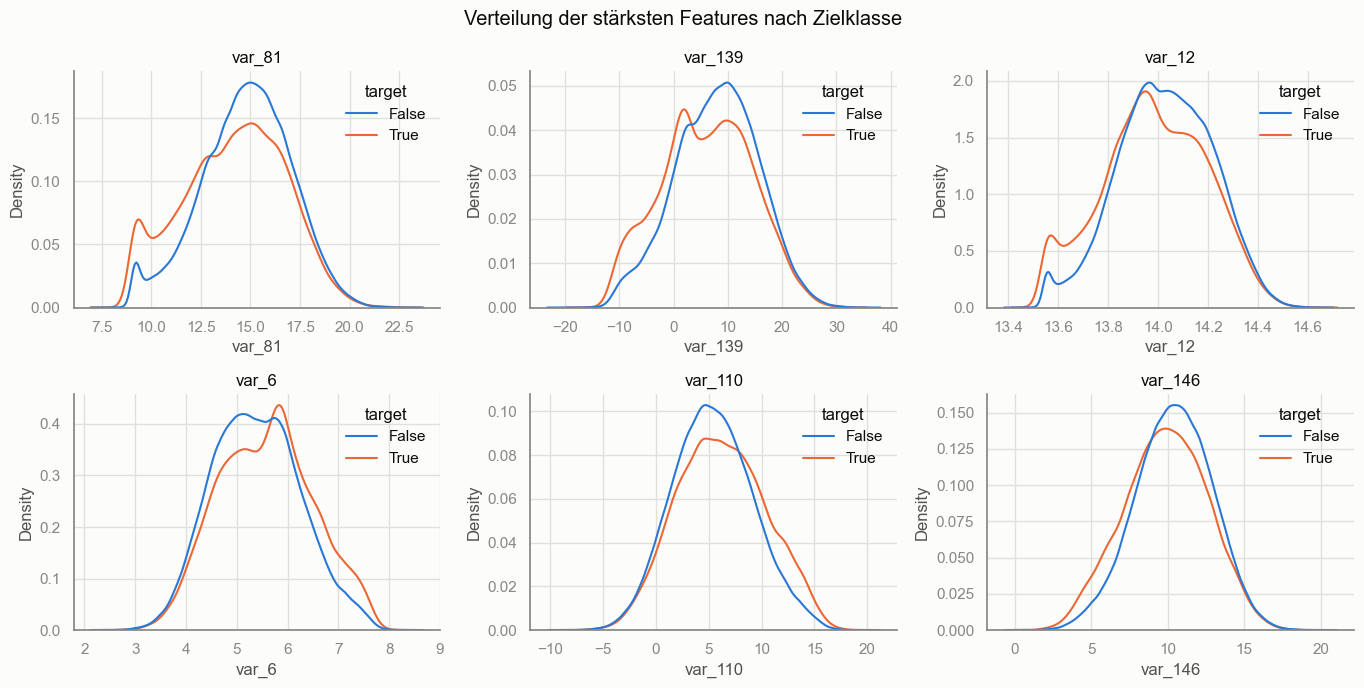

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.flat, top_corr.head(6).index):
    sns.kdeplot(data=df, x=col, hue="target", ax=ax, common_norm=False)
    ax.set_title(col)

plt.suptitle("Verteilung der stärksten Features nach Zielklasse")
plt.tight_layout()
plt.show()

**Information:** Bei den stärksten Features verschieben sich die Verteilungen zwischen
`target=False` und `target=True` sichtbar, überlappen sich aber stark — einzelne Features
trennen die Klassen nicht scharf, liefern aber ein nutzbares Signal für ein Modell, das viele
solcher schwachen Signale kombiniert.

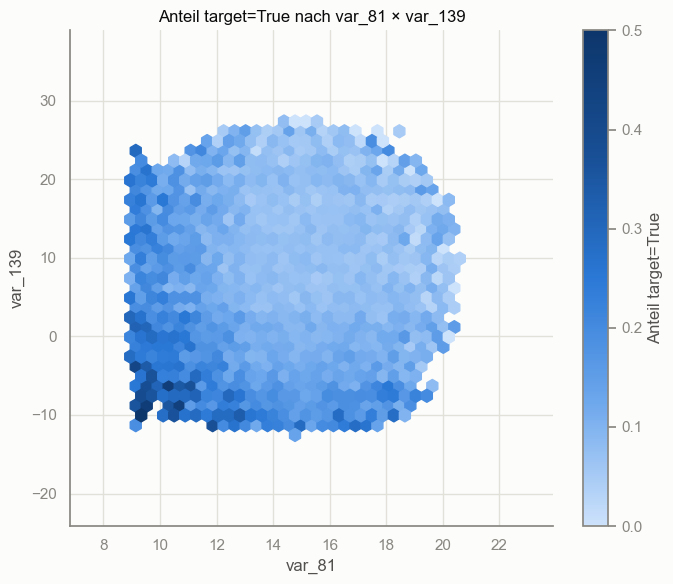

Globaler Anteil target=True: 0.100


In [22]:
top2_features = top_corr.head(2).index

plt.figure(figsize=(7, 6))
hb = plt.hexbin(df[top2_features[0]], df[top2_features[1]], C=df["target"].astype(int),
                 reduce_C_function=np.mean, gridsize=40, cmap=SEQUENTIAL_BLUE, mincnt=20)
plt.colorbar(hb, label="Anteil target=True")
plt.title(f"Anteil target=True nach {top2_features[0]} × {top2_features[1]}")
plt.xlabel(top2_features[0])
plt.ylabel(top2_features[1])
plt.tight_layout()
plt.show()

print(f"Globaler Anteil target=True: {df['target'].mean():.3f}")

**Information:** Anders als der reine (überplottete) Scatter vermuten ließ, zeigt die
dichte-korrigierte Zielrate einen klaren, aber sanften Gradienten: Zeilen mit niedrigen
Werten in beiden Features (unten links) haben eine deutlich höhere `target=True`-Rate als
der globale Schnitt (10 %), Zeilen mit hohen Werten in beiden Features eine niedrigere —
konsistent mit dem negativen Cohen's d beider Features. Der Gradient ist real, aber graduell:
es gibt keine scharfe Trennlinie, sondern eine kontinuierliche Verschiebung der
Wahrscheinlichkeit.

### Effektgrößen (Cohen's d)

In [23]:
grouped = df.groupby("target")[feature_columns]
mean_by_class = grouped.mean().T.rename(columns={False: "mean_false", True: "mean_true"})
std_by_class = grouped.std().T.rename(columns={False: "std_false", True: "std_true"})

n_false, n_true = int((~df["target"]).sum()), int(df["target"].sum())
pooled_std = np.sqrt(
    ((n_false - 1) * std_by_class["std_false"] ** 2 + (n_true - 1) * std_by_class["std_true"] ** 2)
    / (n_false + n_true - 2)
)

effect_sizes = mean_by_class.join(std_by_class)
effect_sizes["cohens_d"] = (effect_sizes["mean_true"] - effect_sizes["mean_false"]) / pooled_std
effect_sizes["abs_cohens_d"] = effect_sizes["cohens_d"].abs()
effect_sizes = effect_sizes.sort_values("abs_cohens_d", ascending=False)

effect_sizes.head(10).round(4)

target,mean_false,mean_true,std_false,std_true,cohens_d,abs_cohens_d
var_81,14.7812,14.162300,2.2580,2.5769,-0.2700,0.2700
var_139,7.9505,6.056600,7.5873,8.3316,-0.2471,0.2471
var_12,14.0284,13.984500,0.1874,0.2079,-0.2317,0.2317
var_6,5.3896,5.582000,0.8580,0.9224,0.2224,0.2224
var_110,5.4311,6.248500,3.7760,4.1511,0.2142,0.2142
var_146,10.3948,9.861500,2.4893,2.7229,-0.2121,0.2121
var_53,5.9924,6.153600,0.7563,0.8225,0.2113,0.2113
var_26,-4.1787,-2.949100,5.8478,6.4460,0.2080,0.2080
var_76,6.2152,4.580300,7.8581,8.4834,-0.2063,0.2063
var_174,20.3578,18.893999,7.0648,7.6230,-0.2055,0.2055


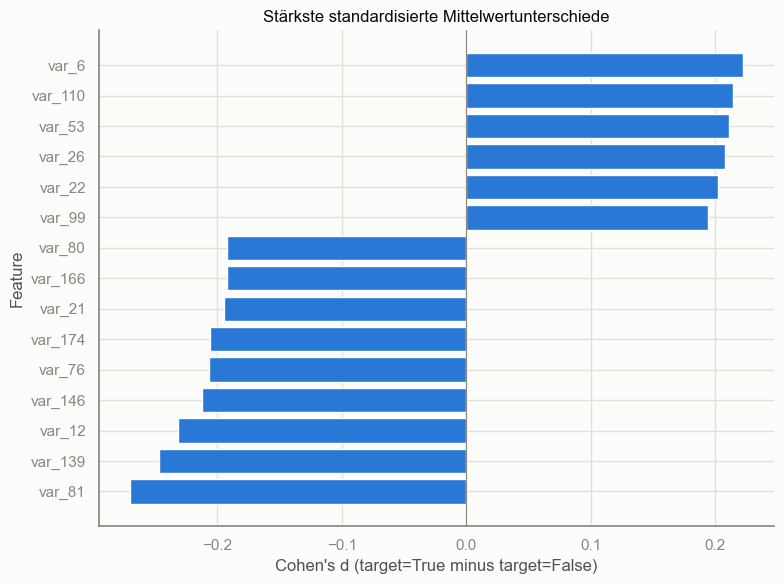

In [24]:
top_effects = effect_sizes.head(15).sort_values("cohens_d")

plt.figure(figsize=(8, 6))
plt.barh(top_effects.index, top_effects["cohens_d"], color=CATEGORICAL[0])
plt.axvline(0, color=INK_MUTED, linewidth=0.8)
plt.title("Stärkste standardisierte Mittelwertunterschiede")
plt.xlabel("Cohen's d (target=True minus target=False)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Information:** Die stärksten Effekte liegen bei Cohen's d ≈ 0,27 (`var_81`) und fallen für
die Top-15-Features nur langsam ab — ein Hinweis, dass das Vorhersagesignal auf viele
schwache Einzelmerkmale verteilt ist statt auf wenige starke.

### Statistische Signifikanz: FDR-Korrektur

Effektgröße (Cohen's d) sagt nichts darüber aus, ob ein Unterschied auch statistisch
absicherbar ist. Das wird hier über alle 200 Features geprüft: ein Welch-t-Test pro Feature,
anschließend eine Benjamini-Hochberg-FDR-Korrektur, um das Problem des multiplen Testens
(200 gleichzeitige Tests) zu berücksichtigen.

In [25]:
p_values = []
for feature in feature_columns:
    values_false = df.loc[~df["target"], feature]
    values_true = df.loc[df["target"], feature]
    _, p = ttest_ind(values_true, values_false, equal_var=False)
    p_values.append(p)

p_values = pd.Series(p_values, index=feature_columns)
p_adjusted = pd.Series(false_discovery_control(p_values, method="bh"), index=feature_columns)

n_raw_significant = int((p_values < 0.05).sum())
n_fdr_significant = int((p_adjusted < 0.05).sum())
print(f"Signifikant bei rohem p < 0,05: {n_raw_significant} von 200")
print(f"Signifikant nach FDR-Korrektur (Benjamini-Hochberg) < 0,05: {n_fdr_significant} von 200")

fdr_table = pd.DataFrame({
    "cohens_d": effect_sizes["cohens_d"],
    "p_value": p_values,
    "p_adjusted": p_adjusted,
}).sort_values("p_adjusted")

not_significant = fdr_table[fdr_table["p_adjusted"] >= 0.05]
print(f"\nNicht signifikante Features (n={len(not_significant)}):")
not_significant.round(6)

Signifikant bei rohem p < 0,05: 181 von 200
Signifikant nach FDR-Korrektur (Benjamini-Hochberg) < 0,05: 181 von 200

Nicht signifikante Features (n=19):


,cohens_d,p_value,p_adjusted
var_124,0.014029,0.060524,0.066510
var_161,0.013863,0.063456,0.069351
var_39,-0.013605,0.068419,0.074369
var_98,-0.013550,0.071136,0.076904
var_158,-0.012694,0.088284,0.094929
var_136,-0.011822,0.113879,0.121796
var_7,-0.010061,0.176535,0.187062
var_96,0.010102,0.176773,0.187062
var_117,0.008619,0.250680,0.263874
var_100,0.007368,0.321843,0.336872


**Information:** 181 von 200 Features sind signifikant — sowohl vor als auch nach
FDR-Korrektur, praktisch kein Unterschied zwischen beiden. Der Grund liegt in der
Stichprobengröße: bei n=200.000 hat der Test enorme statistische Power, selbst ein winziger
Cohen's d von rund 0,01 wird bereits "signifikant". Statistische Signifikanz ist hier also
kein brauchbares Kriterium, um wichtige von unwichtigen Features zu unterscheiden — das
rechtfertigt im Nachhinein, warum in diesem Notebook durchgehend Cohen's d statt p-Werte als
Rangierungskriterium verwendet wird. Der eigentliche Mehrwert dieser Prüfung liegt in den
verbleibenden 19 nicht signifikanten Features: das sind die einzigen, bei denen selbst diese
hohe Power keinen Unterschied zu `target` nachweisen kann — die also mit größter
Wahrscheinlichkeit tatsächlich irrelevant sein könnten. Wenn man einen Ansatz mit weniger
Features ausprobieren möchte, könnte man hier ansetzen und mit einer Feature Importance
verifizieren.

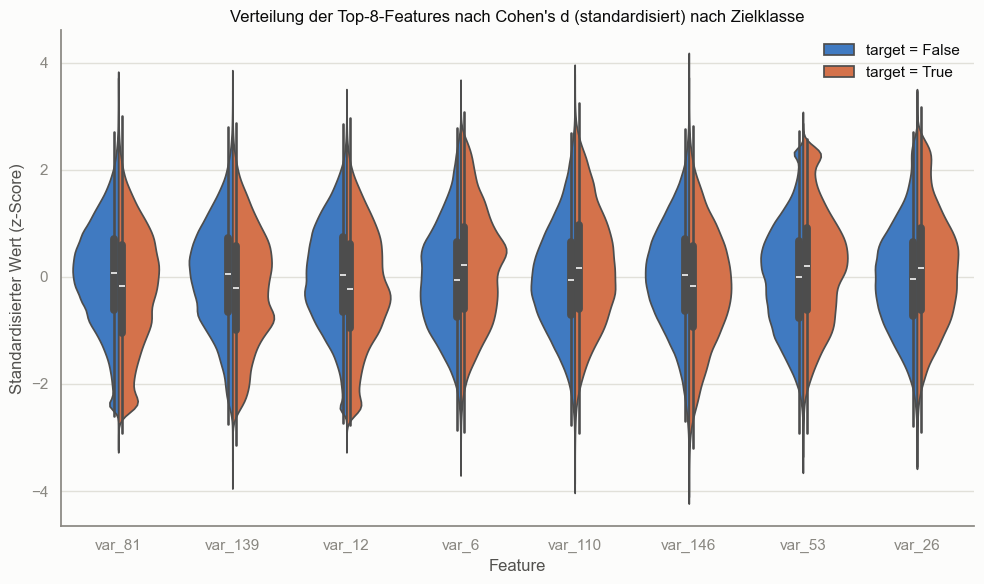

In [26]:
top_violin_features = effect_sizes.head(8).index

standardized = (df[top_violin_features] - df[top_violin_features].mean()) / df[top_violin_features].std()
standardized["target"] = df["target"].map({False: "target = False", True: "target = True"})

melted = standardized.melt(id_vars="target", var_name="Feature", value_name="Standardisierter Wert")

plt.figure(figsize=(10, 6))
sns.violinplot(data=melted, x="Feature", y="Standardisierter Wert", hue="target", split=True,
                palette=CATEGORICAL[:2])
plt.title("Verteilung der Top-8-Features nach Cohen's d (standardisiert) nach Zielklasse")
plt.xlabel("Feature")
plt.ylabel("Standardisierter Wert (z-Score)")
plt.legend(title="")
plt.tight_layout()
plt.show()

**Information:** Der Split-Violin-Plot zeigt Effektgröße und Verteilungsform gemeinsam: bei
allen acht Features ist die Verschiebung zwischen den beiden Zielklassen sichtbar, aber
durchweg klein gegenüber der Streuung innerhalb jeder Klasse — deckt sich mit den moderaten
Cohen's-d-Werten (~0,2–0,27). Die Z-Standardisierung ist hier angemessen: Schiefe (|Skew| ≤ 0,23)
und Ausreißeranteil (≤ 0,4 %) sind für alle acht Features gering, eine robuste Skalierung
(Median/IQR) würde keinen Vorteil bringen.

### Verteilungsform der stärksten Features

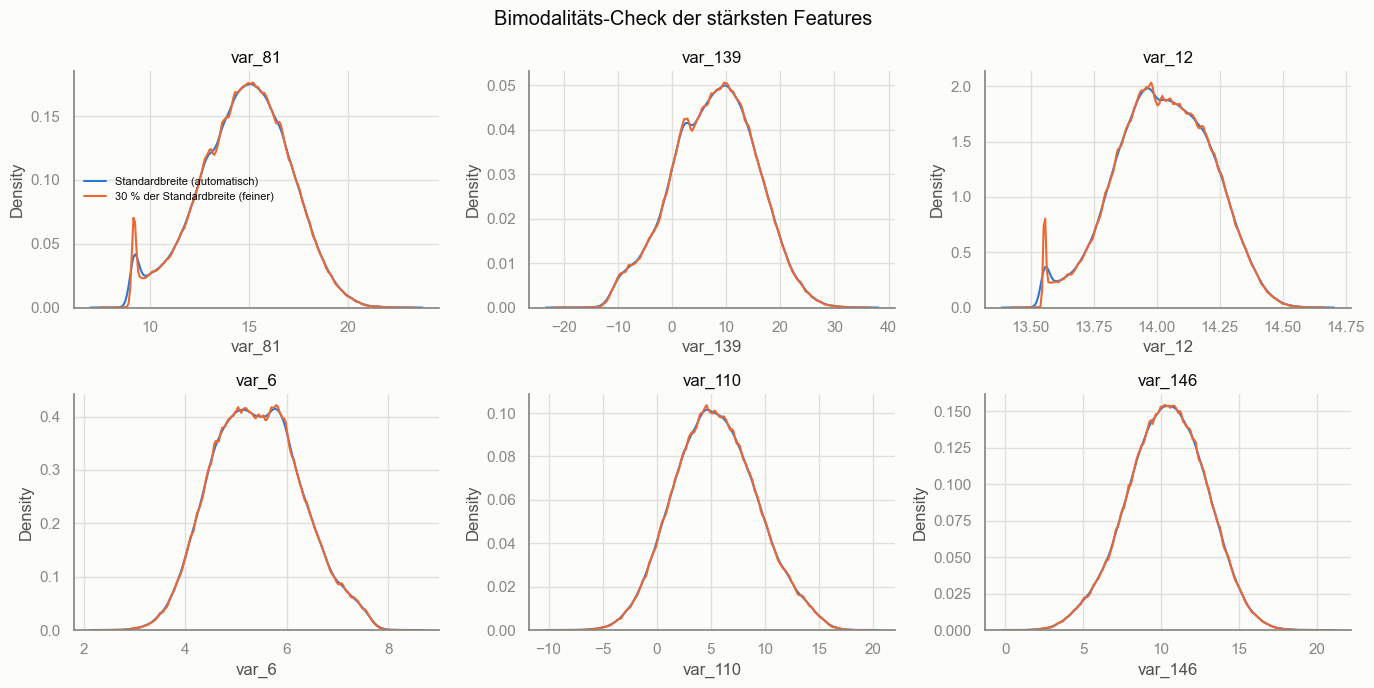

In [27]:
top_features = effect_sizes.head(6).index

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.flat, top_features):
    sns.kdeplot(data=df, x=col, bw_adjust=1.0, ax=ax, color=CATEGORICAL[0], label="Standardbreite (automatisch)")
    sns.kdeplot(data=df, x=col, bw_adjust=0.3, ax=ax, color=CATEGORICAL[1], label="30 % der Standardbreite (feiner)")
    ax.set_title(col)

axes.flat[0].legend(fontsize=8)
plt.suptitle("Bimodalitäts-Check der stärksten Features")
plt.tight_layout()
plt.show()

**Information:** Die Standardbreite wird automatisch nach einer statistischen Faustregel
berechnet und glättet bewusst konservativ, um zufälliges Rauschen nicht als Struktur
darzustellen; die feinere Bandbreite (30 % davon) zeigt mehr lokale Details, ist aber auch
anfälliger dafür, Rauschen fälschlich als Struktur zu zeigen. Deshalb der Vergleich: taucht
eine Ausbeulung nur bei der feinen, aggressiven Glättung auf, ist sie vermutlich Rauschen —
bleibt sie auch bei der konservativen Standardbreite sichtbar, ist das ein starkes Indiz für
echte Struktur. `var_81` und `var_12` zeigen einen deutlichen zweiten Verteilungsgipfel, der
auch bei Standard-Bandbreite erhalten bleibt (also kein Glättungsartefakt) — ein Hinweis auf
verborgene Subpopulationen innerhalb dieser Features, die über den reinen Mittelwertvergleich
(Cohen's d) hinausgehen.

**Idee für die Modellierung:** Für lineare Modelle ist ein Split am Tal zwischen den beiden
Gipfeln (z. B. als zusätzliches binäres Feature) möglich, um die Zwei-Gruppen-Struktur
explizit zugänglich zu machen. Baumbasierte Modelle (Random Forest, Gradient Boosting)
können an dieser Stelle selbst splitten und benötigen diese manuelle Vorverarbeitung
vermutlich nicht.

### Nichtlineare Assoziation: Mutual Information

Cohen's d und die Korrelation weiter oben messen nur lineare Mittelwertunterschiede.
Mutual Information ergänzt das um nichtlineare Abhängigkeiten, die eine reine
Mittelwertbetrachtung übersehen kann.

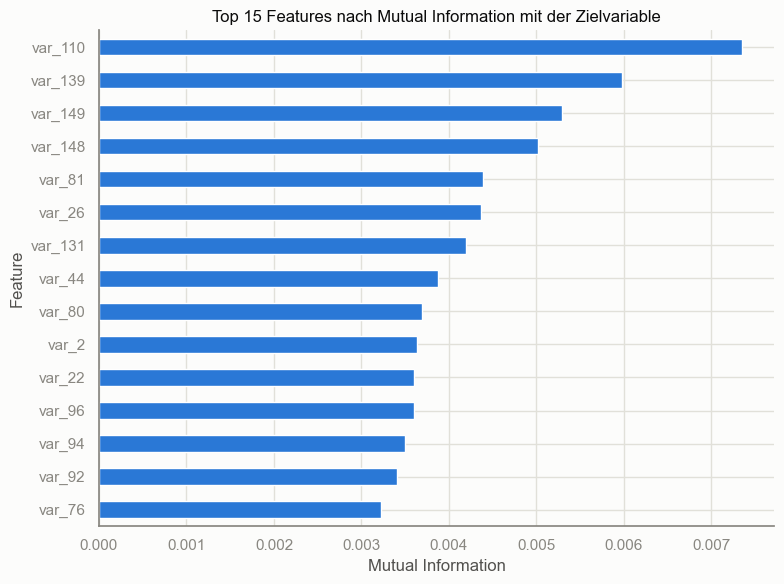

Rangkorrelation zwischen Mutual Information und |Cohen's d|: 0.411
var_81: MI-Rang 5, Cohen's-d-Rang 1
var_12: MI-Rang 26, Cohen's-d-Rang 3


In [28]:
mi_sample = df.sample(n=50_000, random_state=42)

mi_values = mutual_info_classif(
    mi_sample[feature_columns], mi_sample["target"].astype(int), random_state=42
)
mutual_information = pd.Series(mi_values, index=feature_columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
mutual_information.head(15).sort_values().plot(kind="barh", color=CATEGORICAL[0])
plt.title("Top 15 Features nach Mutual Information mit der Zielvariable")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "mutual_information": mutual_information,
    "abs_cohens_d": effect_sizes["abs_cohens_d"],
})
rank_correlation = comparison.rank().corr().iloc[0, 1]
print(f"Rangkorrelation zwischen Mutual Information und |Cohen's d|: {rank_correlation:.3f}")

for feature in ["var_81", "var_12"]:
    mi_rank = int(mutual_information.rank(ascending=False)[feature])
    cohens_d_rank = int(effect_sizes["abs_cohens_d"].rank(ascending=False)[feature])
    print(f"{feature}: MI-Rang {mi_rank}, Cohen's-d-Rang {cohens_d_rank}")

**Information:** Die Rangkorrelation zwischen Mutual Information und |Cohen's d| liegt nur bei
0,411 — moderat, nicht hoch. Lineares und nichtlineares Maß bewerten die Feature-Wichtigkeit
also spürbar unterschiedlich, nicht nur bei einzelnen Ausreißern. Die konkrete Vermutung von
vorhin (bimodale Features würden in der MI-Rangliste eher *höher* stehen als bei Cohen's d)
bestätigt sich **nicht** — im Gegenteil: `var_81` fällt von Rang 1 (Cohen's d) auf Rang 5
(MI), `var_12` sogar von Rang 3 auf Rang 26. Andere, in der Cohen's-d-Sicht unauffälligere
Features tragen also mehr nichtlineare Information über `target`, als ihr Mittelwertunterschied
vermuten lässt — ein echter Zusatzbefund, der eine rein lineare Rangliste allein nicht
geliefert hätte.

### Gesamtbild: PCA-Projektion

Rein exploratives 2D-Bild der Trennbarkeit über alle 200 Features hinweg — hier wird PCA
ausschließlich zur Visualisierung genutzt, nicht zur Verbesserung eines Modells (das bleibt
Teil der separaten Modellierung).

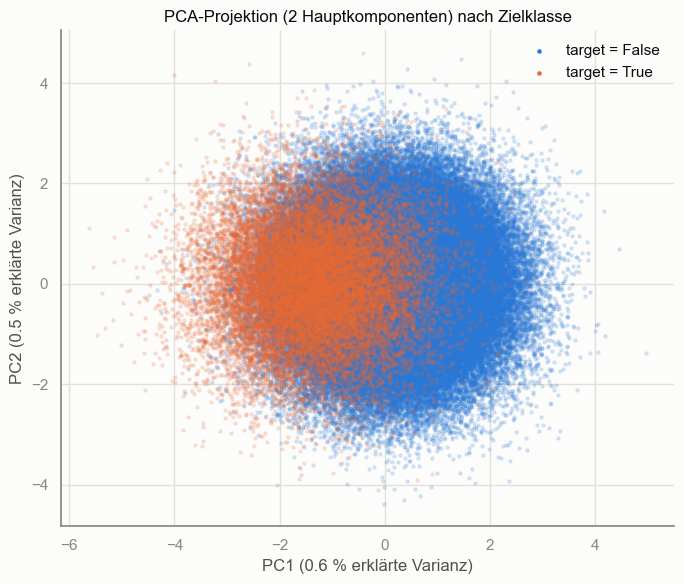

In [29]:
pca_input = StandardScaler().fit_transform(df[feature_columns])
pca = PCA(n_components=2, random_state=42)
pca_scores = pca.fit_transform(pca_input)

plt.figure(figsize=(7, 6))
for is_true, label, color in [(False, "target = False", CATEGORICAL[0]), (True, "target = True", CATEGORICAL[1])]:
    mask = (df["target"] == is_true).to_numpy()
    plt.scatter(pca_scores[mask, 0], pca_scores[mask, 1], alpha=0.15, s=5, label=label, color=color)

plt.title("PCA-Projektion (2 Hauptkomponenten) nach Zielklasse")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f} % erklärte Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f} % erklärte Varianz)")
legend = plt.legend()
for handle in legend.legend_handles:
    handle.set_alpha(1)
plt.tight_layout()
plt.show()

In [30]:
pc1_loadings = pd.Series(pca.components_[0], index=feature_columns)
loading_effect_corr = pc1_loadings.corr(effect_sizes["cohens_d"])
print(f"Korrelation zwischen PC1-Ladung und Cohen's d je Feature: {loading_effect_corr:.3f}")

Korrelation zwischen PC1-Ladung und Cohen's d je Feature: -0.989


**Information:** PC1 und PC2 erklären zusammen nur ~1,1 % der Gesamtvarianz — erwartbar, da
die Features praktisch unkorreliert sind und PCA bei fehlender Redundanz kaum komprimieren
kann. Trotzdem zeigt sich ein sichtbarer Dichteunterschied entlang PC1: `target=True`-Punkte
konzentrieren sich eher im negativen Bereich. Verifiziert statt nur vermutet: die Korrelation
zwischen PC1-Ladung und Cohen's d je Feature liegt bei **-0,989** — PC1 ist damit praktisch
identisch mit der gewichteten Summe der Einzelfeature-Effekte aus dem vorigen Abschnitt. Der
PC1-Gradient ist also keine neue Information, sondern die aggregierte Darstellung der
bereits bekannten schwachen Einzelsignale.

## Häufigkeitsstruktur der Werte

Obwohl alle Features numerisch sind, wiederholen sich viele Werte innerhalb einer Spalte.
Dieser Abschnitt prüft, ob diese Duplikat-Struktur mit der Zielvariable zusammenhängt — ein
bekannter Effekt bei diesem Datensatz, bei dem Werte-Häufigkeiten im ursprünglichen
Wettbewerb als zusätzliches Merkmal genutzt wurden. Der eigentliche "Magic Feature"-Ansatz
aus dem Original-Wettbewerb nutzte zusätzlich einen Trick, echte von synthetisch erzeugten
Testzeilen zu unterscheiden — das setzt ein unetikettiertes Testset voraus. Diese
OpenML-Version (`45566`) enthält ausschließlich beschriftete Zeilen (`df.shape` zeigt
200.000 Zeilen, alle mit `target`), weshalb dieser spezielle Trick hier nicht anwendbar ist
und bewusst nicht nachgebildet wird.

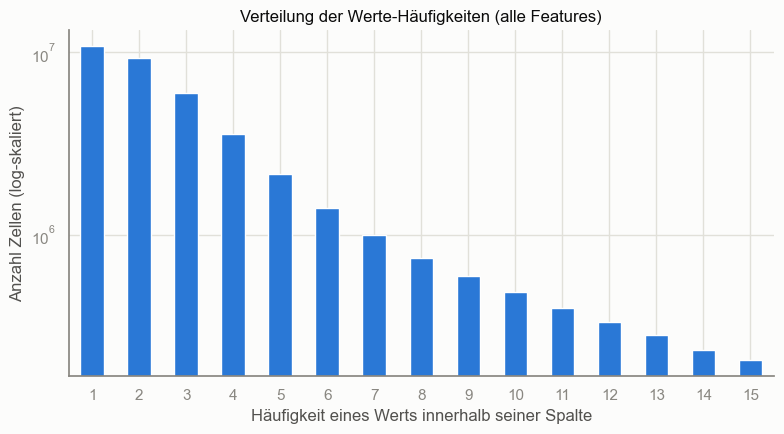

Anteil einzigartiger Zellen: 27.1 %


In [31]:
value_occurrence = pd.DataFrame(
    {col: df[col].map(df[col].value_counts()) for col in feature_columns},
    index=df.index,
)

occurrence_distribution = (
    pd.Series(value_occurrence.to_numpy().ravel(), dtype="int32").value_counts().sort_index()
)

plt.figure(figsize=(8, 4.5))
occurrence_distribution.head(15).plot(kind="bar", color=CATEGORICAL[0])
plt.title("Verteilung der Werte-Häufigkeiten (alle Features)")
plt.xlabel("Häufigkeit eines Werts innerhalb seiner Spalte")
plt.ylabel("Anzahl Zellen (log-skaliert)")
plt.yscale("log")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

unique_share = (value_occurrence.to_numpy() == 1).mean() * 100
print(f"Anteil einzigartiger Zellen: {unique_share:.1f} %")

**Information:** 27,1 % aller Werte sind einzigartig, der Rest wiederholt sich mindestens
einmal — bei rein zufälligen Fließkommawerten wäre praktisch jeder Wert einzigartig. Diese
unerwartet hohe Duplikat-Rate motiviert die weitere Untersuchung, ob sie mit `target`
zusammenhängt.

Der vorige Plot zeigt nur, wie häufig Häufigkeiten insgesamt sind — nicht, ob seltenere oder
häufigere Werte eher mit `target=True` oder `target=False` einhergehen. Das wird jetzt direkt
geprüft: alle Zellen werden nach dem Vorkommen ihres Werts in Häufigkeitsbereiche einsortiert,
und für jeden Bereich wird der tatsächliche Anteil `target=True` berechnet.

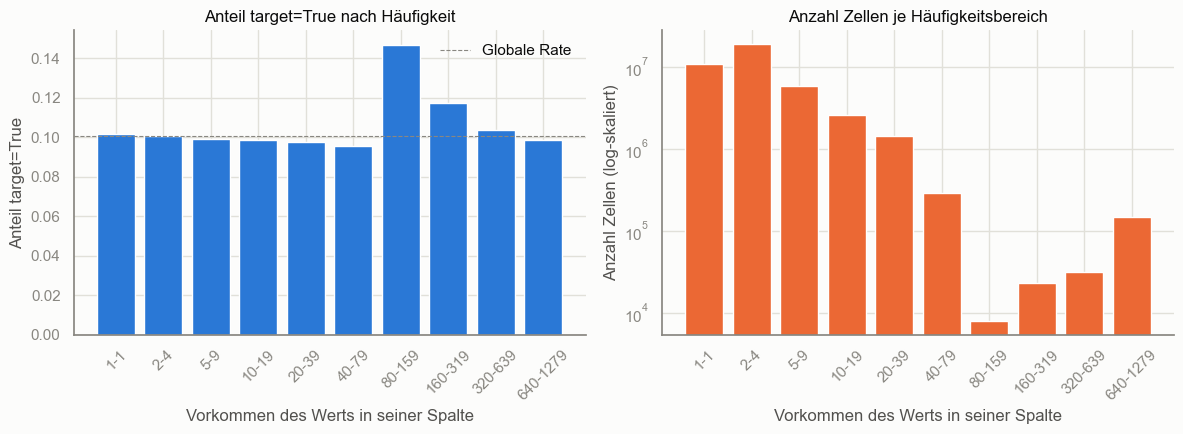

,target_true_rate,n_cells
1-1,0.1019,10832700
2-4,0.1007,18800504
5-9,0.0990,5900869
10-19,0.0986,2560140
20-39,0.0976,1412539
40-79,0.0953,285677
80-159,0.1468,7989
160-319,0.1176,22899
320-639,0.1035,31184
640-1279,0.0986,145499


In [32]:
occurrence_flat = value_occurrence.to_numpy().ravel()
target_flat = np.repeat(df["target"].to_numpy(), len(feature_columns))

bin_edges = [1, 2, 5, 10, 20, 40, 80, 160, 320, 640, 1280]
bin_labels = [f"{bin_edges[i]}-{bin_edges[i + 1] - 1}" for i in range(len(bin_edges) - 1)]
bin_index = np.digitize(occurrence_flat, bin_edges[1:-1])

occurrence_summary = (
    pd.DataFrame({"target": target_flat, "bin": bin_index})
    .groupby("bin")["target"].agg(["mean", "count"])
    .rename(columns={"mean": "target_true_rate", "count": "n_cells"})
)
occurrence_summary.index = bin_labels

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(occurrence_summary.index, occurrence_summary["target_true_rate"], color=CATEGORICAL[0])
axes[0].axhline(df["target"].mean(), color=INK_MUTED, linewidth=0.8, linestyle="--", label="Globale Rate")
axes[0].set_title("Anteil target=True nach Häufigkeit")
axes[0].set_xlabel("Vorkommen des Werts in seiner Spalte")
axes[0].set_ylabel("Anteil target=True")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].bar(occurrence_summary.index, occurrence_summary["n_cells"], color=CATEGORICAL[1])
axes[1].set_yscale("log")
axes[1].set_title("Anzahl Zellen je Häufigkeitsbereich")
axes[1].set_xlabel("Vorkommen des Werts in seiner Spalte")
axes[1].set_ylabel("Anzahl Zellen (log-skaliert)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

occurrence_summary.round(4)

**Information:** Zwei klar unterscheidbare Bereiche. Von Häufigkeit 1 bis etwa 79 fällt der
Anteil `target=True` leicht, aber stetig (0,102 → 0,095) — bei Millionen Zellen pro
Häufigkeitsbereich ist diese kleine Verschiebung statistisch weit von reinem Zufall entfernt:
seltenere Werte gehen tendenziell eher mit `target=True` einher. Ab Häufigkeit 80 springen die
Werte dagegen unruhig (bis 0,147), weil die Zellenzahl dort auf wenige Tausend einbricht (siehe
rechte Grafik, log-skaliert) — vermutlich getragen von einzelnen konzentrierten Features wie
`var_68`. Dieser Teil ist zu klein besetzt, um belastbar zu sein, und sollte nicht als echter
Effekt gewertet werden.

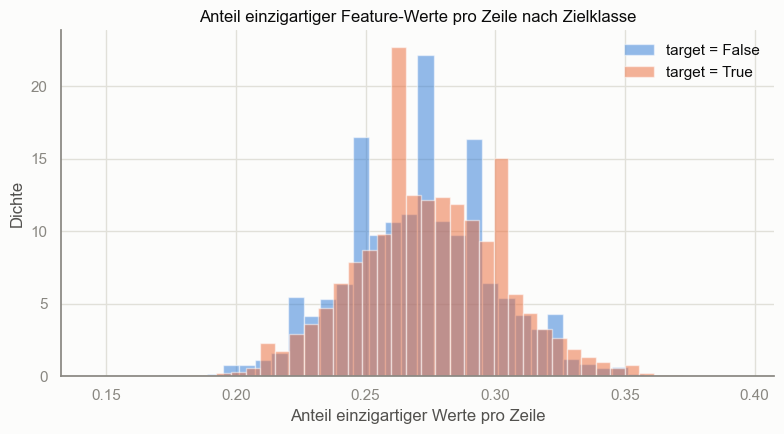

,mean,median,std
target,,,
False,0.2704,0.270,0.0283
True,0.2746,0.275,0.0284


In [33]:
unique_share_per_row = value_occurrence.eq(1).mean(axis=1)

plt.figure(figsize=(8, 4.5))
for is_true, label in [(False, "target = False"), (True, "target = True")]:
    plt.hist(unique_share_per_row[df["target"] == is_true], bins=40,
             density=True, alpha=0.5, label=label)

plt.title("Anteil einzigartiger Feature-Werte pro Zeile nach Zielklasse")
plt.xlabel("Anteil einzigartiger Werte pro Zeile")
plt.ylabel("Dichte")
plt.legend()
plt.tight_layout()
plt.show()

unique_share_per_row.groupby(df["target"]).agg(["mean", "median", "std"]).round(4)

**Information:** Zeilen mit `target=True` haben im Mittel einen um ~1,5 % höheren Anteil
einzigartiger Werte (0,2746 vs. 0,2704) als `target=False`-Zeilen — ein kleiner, aber
konsistenter Aggregat-Unterschied über alle 200 Features hinweg.

Der Effekt ist im Aggregat über alle 200 Features sichtbar. Ob er sich auch bei einem
einzelnen, stark konzentrierten Feature nachweisen lässt, wird am Beispiel von `var_68`
geprüft — dem Feature mit der niedrigsten Kardinalität im Datensatz. Gezeigt werden sowohl die
absolute als auch die relative Häufigkeit nebeneinander: die absolute Zahl ist wegen der
9:1-Klassenungleichheit allein nicht fair vergleichbar, deshalb wird zusätzlich die relative
Häufigkeit (Anteil der jeweiligen Gruppe) berechnet — nur Werte mit ausreichend vielen
Vorkommen (≥ 50) werden einbezogen.

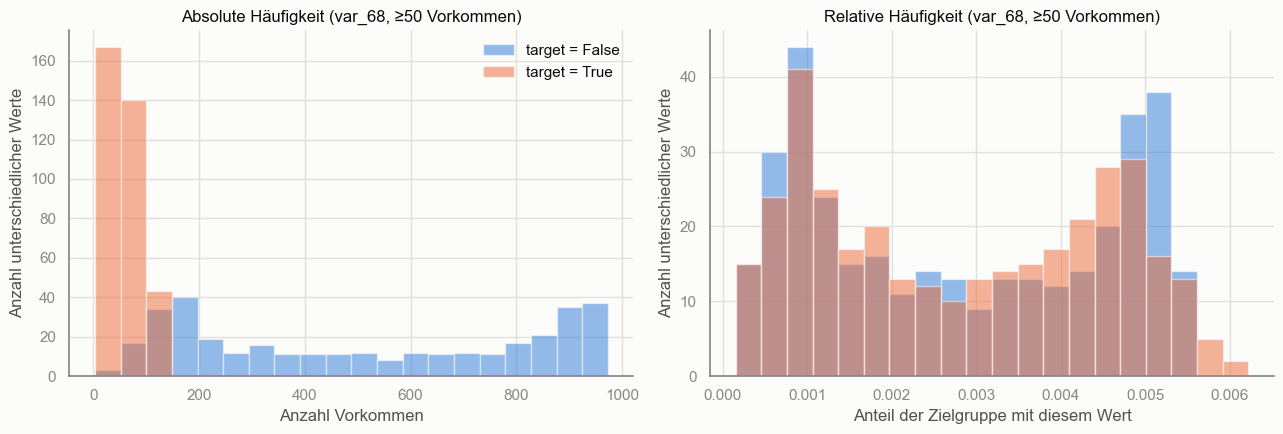

n = 350 Werte
mittlere absolute Häufigkeit | target=False: 511.3  target=True: 57.1
mittlerer Anteil             | target=False: 0.00284  target=True: 0.00284


In [34]:
selected_feature = "var_68"
min_occurrence = 50

total_counts = df[selected_feature].value_counts()
qualifying_values = total_counts[total_counts >= min_occurrence].index

count_false = df.loc[~df["target"], selected_feature].value_counts().reindex(qualifying_values, fill_value=0)
count_true = df.loc[df["target"], selected_feature].value_counts().reindex(qualifying_values, fill_value=0)

rate_false = count_false / n_false
rate_true = count_true / n_true

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

abs_bin_edges = np.histogram_bin_edges(pd.concat([count_false, count_true]), bins=20)
axes[0].hist(count_false, bins=abs_bin_edges, alpha=0.5, label="target = False", color=CATEGORICAL[0])
axes[0].hist(count_true, bins=abs_bin_edges, alpha=0.5, label="target = True", color=CATEGORICAL[1])
axes[0].set_title(f"Absolute Häufigkeit ({selected_feature}, ≥{min_occurrence} Vorkommen)")
axes[0].set_xlabel("Anzahl Vorkommen")
axes[0].set_ylabel("Anzahl unterschiedlicher Werte")
axes[0].legend()

rel_bin_edges = np.histogram_bin_edges(pd.concat([rate_false, rate_true]), bins=20)
axes[1].hist(rate_false, bins=rel_bin_edges, alpha=0.5, label="target = False", color=CATEGORICAL[0])
axes[1].hist(rate_true, bins=rel_bin_edges, alpha=0.5, label="target = True", color=CATEGORICAL[1])
axes[1].set_title(f"Relative Häufigkeit ({selected_feature}, ≥{min_occurrence} Vorkommen)")
axes[1].set_xlabel("Anteil der Zielgruppe mit diesem Wert")
axes[1].set_ylabel("Anzahl unterschiedlicher Werte")

plt.tight_layout()
plt.show()

print(f"n = {len(qualifying_values)} Werte")
print(f"mittlere absolute Häufigkeit | target=False: {count_false.mean():.1f}  target=True: {count_true.mean():.1f}")
print(f"mittlerer Anteil             | target=False: {rate_false.mean():.5f}  target=True: {rate_true.mean():.5f}")

**Information:** Die absoluten Zahlen (links) sehen auf den ersten Blick nach einem deutlichen
Unterschied aus (Ø 511 vs. 57 Vorkommen) — das ist ein Artefakt der 9:1-Klassengröße. Erst der
relative Vergleich (rechts) zeigt das eigentliche Bild: der mittlere Anteil ist für beide
Zielklassen praktisch identisch (0,00284 vs. 0,00284) — der Aggregat-Effekt aus dem vorigen
Plot lässt sich bei diesem Einzelfeature nicht reproduzieren.

In [35]:
concentrated_features = concentration.sort_values("unique_values").head(6).index
min_occurrence = 50

results = []
for feature in concentrated_features:
    total_counts = df[feature].value_counts()
    qualifying_values = total_counts[total_counts >= min_occurrence].index

    rate_false = (
        df.loc[~df["target"], feature].value_counts()
        .reindex(qualifying_values, fill_value=0) / n_false
    )
    rate_true = (
        df.loc[df["target"], feature].value_counts()
        .reindex(qualifying_values, fill_value=0) / n_true
    )

    _, p_value = mannwhitneyu(rate_false, rate_true)
    results.append({
        "feature": feature,
        "n_values": len(qualifying_values),
        "mean_rate_false": rate_false.mean(),
        "mean_rate_true": rate_true.mean(),
        "p_value": p_value,
    })

pd.DataFrame(results).round(6)

,feature,n_values,mean_rate_false,mean_rate_true,p_value
0,var_68,350,0.002842,0.002841,0.935495
1,var_91,463,0.000267,0.000264,0.019234
2,var_108,141,0.000369,0.000489,0.087945
3,var_103,43,0.000262,0.000250,0.194053
4,var_12,123,0.000296,0.000393,0.073379
5,var_148,65,0.000264,0.000231,0.010138


**Information:** Die Tabelle wiederholt den Vergleich für die sechs Features mit der
niedrigsten Kardinalität. Kein p-Wert übersteht eine Bonferroni-Korrektur für sechs Tests
(Signifikanzniveau 0,05/6 ≈ 0,0083); die kleinsten Stichproben (`var_103`, `var_148`) liefern
zudem zu wenige qualifizierende Werte, um überhaupt belastbar zu sein. Der Zusammenhang
zwischen Werte-Häufigkeit und Zielvariable lässt sich damit nur im Aggregat über alle Features
nachweisen (siehe oben), nicht bei einzelnen Merkmalen isoliert.

#### Als Parquet Objekt abspeichern

In [ ]:
df.to_parquet("data_clean.parquet")

## Fazit

### Wichtigste Befunde

- Der Datensatz ist vollständig sauber (keine fehlenden, duplizierten, nicht-finiten oder
  konstanten Werte) und mit rund 9:1 deutlich unausgeglichen.
- Ausreißer spielen praktisch keine Rolle (Median-Anteil 0,02 %); die 200 Features sind
  untereinander praktisch unabhängig (alle Korrelationen < 0,05, kein Paar mit |r| ≥ 0,8).
- Das Vorhersagesignal ist über viele schwache Features verteilt statt auf wenige starke
  konzentriert (Cohen's d bis rund 0,27); 181 von 200 Features sind FDR-korrigiert signifikant
  von `target` verschieden, allerdings bei n=200.000 mit entsprechend geringer Aussagekraft der
  reinen Signifikanz.
- Mutual Information (Rangkorrelation zu |Cohen's d| nur 0,411) und eine erkennbare Bimodalität
  bei `var_81`/`var_12` zeigen, dass lineare Maße die Feature-Wichtigkeit nicht vollständig
  erfassen. Die Häufigkeit, mit der ein Wert innerhalb seiner Spalte vorkommt, hängt schwach,
  aber robust mit `target` zusammen (Bereich 1–79 Vorkommen).

### Ideen für die Modellierung

1. **Bewertungsmetrik:** AUC-ROC statt Accuracy verwenden (9:1-Ungleichgewicht macht Accuracy
   irreführend); zusätzlich `class_weight="balanced"` oder Resampling-Strategien in Betracht
   ziehen.
2. **Skalierung:** Einfache Standardisierung (z-Score) reicht aus — der Ausreißeranteil ist
   vernachlässigbar, eine robuste Skalierung (Median/IQR) bringt keinen Mehrwert.
3. **Kein Multikollinearitäts-Handling nötig:** Da die Features praktisch unabhängig sind und
   PCA nachweislich keine neue Information liefert (PC1 korreliert mit -0,989 nur mit der
   bereits bekannten Cohen's-d-Struktur), erübrigt sich eine Redundanzreduktion vor dem
   Training.
4. **Ensembles/Boosting bevorzugen:** Da das Signal auf viele schwache Einzelmerkmale verteilt
   ist, sollten Modelle, die viele schwache Signale kombinieren (Gradient Boosting, Random
   Forest, regularisierte lineare Modelle mit allen Features), besser abschneiden als Ansätze,
   die auf wenige dominante Prädiktoren setzen.
5. **Nichtlineare Modelle oder gezieltes Feature-Engineering testen:** Die nur moderate
   Übereinstimmung zwischen Mutual Information und Cohen's d deutet darauf hin, dass ein rein
   lineares Modell (z. B. logistische Regression ohne Interaktionsterme) Signal verschenken
   könnte, das baumbasierte Modelle oder explizite Interaktions-/Nichtlinearitäts-Features
   erfassen würden.
6. **Bimodalität explizit codieren:** Für lineare Modelle `var_81`/`var_12` um ein zusätzliches
   binäres Feature (Split am Tal zwischen den beiden Verteilungsgipfeln) ergänzen; baumbasierte
   Modelle können diese Struktur vermutlich selbst abbilden.
7. **Count-/Frequency-Encoding ausprobieren:** Gezielt für den Häufigkeitsbereich 1–79
   Vorkommen ein zusätzliches Feature aus der Werte-Häufigkeit ableiten — dort ist der
   Zusammenhang mit `target` statistisch robust (wenn auch klein), außerhalb dieses Bereichs
   nicht belastbar genug für eine pauschale Transformation.
8. **Feature-Selektion vorsichtig angehen:** Die 19 FDR-nicht-signifikanten Features sind
   Kandidaten für eine Reduktion, sollten aber nicht allein anhand eines linearen Kriteriums
   entfernt werden — vor einer endgültigen Entscheidung mit multivariater Feature Importance
   (z. B. Permutation Importance an einem trainierten Modell) absichern, da univariate Maße
   nichtlineare oder Interaktionseffekte übersehen können.